# Thực hành 8.1: Ước lượng Chuyển động & Luồng quang học truyền thống

**Mục tiêu:** Nắm vững cách máy tính hiểu sự dịch chuyển của điểm ảnh qua các khung hình và cách trích xuất luồng quang học bằng OpenCV.

## 1. Khởi tạo môi trường và Xử lý dữ liệu Video cơ bản
Video thực chất là sự mở rộng của hình ảnh tĩnh dọc theo trục thời gian. Nếu một bức ảnh tĩnh được biểu diễn bằng hàm không gian 2D $f(x,y)$, thì video là một hàm 3D $f(x,y,t)$, mô tả sự thay đổi của cường độ điểm ảnh qua từng thời điểm $t$. Đặc trưng độc quyền của video so với ảnh tĩnh chính là **thông tin chuyển động (motion information)**.

Trong phần này, chúng ta sẽ thiết lập môi trường và viết các hàm cơ bản để "mổ xẻ" video thành các khung hình (frames) tĩnh.

---


### 1.1. Import các thư viện cốt lõi
Để bắt đầu, chúng ta cần nạp các thư viện cần thiết:
*   **`cv2` (OpenCV):** Thư viện cốt lõi cho Thị giác máy tính, chứa các thuật toán đọc video và tính toán luồng quang học.
*   **`numpy`:** Xử lý ma trận dữ liệu đa chiều (các pixel của ảnh).
*   **`matplotlib.pyplot`:** Trực quan hóa kết quả, vẽ biểu đồ và hiển thị các khung hình.

In [81]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cấu hình matplotlib để hiển thị ảnh đẹp hơn trong notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

print(f"Phiên bản OpenCV đang sử dụng: {cv2.__version__}")
print(f"Phiên bản NumPy đang sử dụng: {np.__version__}")

Phiên bản OpenCV đang sử dụng: 4.13.0
Phiên bản NumPy đang sử dụng: 2.0.2


### 1.2. Đọc video từ file hoặc webcam
Trong OpenCV, đối tượng `cv2.VideoCapture` được sử dụng để đọc luồng video. Bạn có thể truyền vào đường dẫn của một file video (ví dụ: `'data/traffic.mp4'`) hoặc truyền số `0` để đọc trực tiếp từ Webcam.

Đầu tiên, hãy viết một đoạn code ngắn để tải một video mẫu và kiểm tra các thông số cơ bản của nó như: FPS (số khung hình/giây), chiều rộng, chiều cao và tổng số khung hình.

*(Lưu ý: Sinh viên cần đảm bảo đã có file video mẫu `sample_traffic.mp4` trong cùng thư mục với notebook, hoặc thay đổi đường dẫn cho phù hợp).*

In [82]:
# Đường dẫn tới video mẫu (Giảng viên có thể chuẩn bị sẵn file này)
video_path = 'sample_traffic.mp4'

# Khởi tạo đối tượng VideoCapture
cap = cv2.VideoCapture(video_path)

# Kiểm tra xem video có mở thành công không
if not cap.isOpened():
    print(f"Lỗi: Không thể mở video tại đường dẫn '{video_path}'")
else:
    # Lấy các thông số của video
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print("--- THÔNG TIN VIDEO ---")
    print(f"Độ phân giải: {width}x{height} pixels")
    print(f"Tốc độ khung hình (FPS): {fps}")
    print(f"Tổng số khung hình: {frame_count}")
    print(f"Thời lượng ước tính: {frame_count/fps:.2f} giây")

# Luôn nhớ giải phóng camera/video sau khi lấy xong thông tin
cap.release()

--- THÔNG TIN VIDEO ---
Độ phân giải: 768x576 pixels
Tốc độ khung hình (FPS): 10.0
Tổng số khung hình: 795
Thời lượng ước tính: 79.50 giây


In [83]:
import os
import requests

# Sử dụng link từ kho lưu trữ chính thức của OpenCV
video_url = 'https://github.com/opencv/opencv/raw/master/samples/data/vtest.avi'
video_filename = 'sample_traffic.mp4' # Giữ nguyên tên để không phải sửa các code sau

def download_video(url, filename):
    try:
        print(f"Đang tải video mẫu từ OpenCV: {url}...")
        response = requests.get(url, stream=True, timeout=30)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                for chunk in response.iter_content(chunk_size=1024*1024):
                    if chunk:
                        f.write(chunk)
            print(f"Tải xuống thành công: {filename} ({os.path.getsize(filename)} bytes)")
            return True
        else:
            print(f"Lỗi: Mã trạng thái {response.status_code}")
            return False
    except Exception as e:
        print(f"Lỗi kết nối: {e}")
        return False

# Dọn dẹp file lỗi cũ
if os.path.exists(video_filename):
    os.remove(video_filename)

# Tiến hành tải mới
success = download_video(video_url, video_filename)
if success:
    print("Bây giờ bạn có thể chạy tiếp các ô mã bên dưới.")

Đang tải video mẫu từ OpenCV: https://github.com/opencv/opencv/raw/master/samples/data/vtest.avi...
Tải xuống thành công: sample_traffic.mp4 (8131690 bytes)
Bây giờ bạn có thể chạy tiếp các ô mã bên dưới.


### 1.3. Viết hàm tiện ích: Trích xuất và tiền xử lý khung hình
Để phân tích chuyển động, chúng ta thường chỉ cần so sánh **hai khung hình liên tiếp** (hoặc cách nhau một khoảng stride nhất định).

Bên cạnh đó, các thuật toán tính toán chuyển động truyền thống thường dựa trên **Ràng buộc độ sáng không đổi** (điểm ảnh duy trì cường độ sáng giống nhau khi di chuyển). Do đó, việc xử lý ảnh màu (3 kênh RGB) là không cần thiết và tốn kém tài nguyên. Chúng ta sẽ chuyển đổi ảnh màu sang ảnh xám (Grayscale - 1 kênh) để tối ưu tính toán.

Hãy viết hàm `extract_frames` để lấy ra $N$ khung hình từ video và chuyển sang ảnh xám.

In [84]:
import os
import cv2
import numpy as np

def extract_grayscale_frames(video_path, start_frame=0, num_frames=2, stride=1):
    # Sử dụng đường dẫn tuyệt đối
    abs_path = os.path.abspath(video_path)
    if not os.path.exists(abs_path):
        raise FileNotFoundError(f"Không tìm thấy file tại: {abs_path}")

    if os.path.getsize(abs_path) == 0:
        raise ValueError("File video bị trống (0 bytes). Hãy kiểm tra lại quá trình tải.")

    cap = cv2.VideoCapture(abs_path)

    if not cap.isOpened():
        # Thử lại với backend khác nếu mặc định thất bại
        cap = cv2.VideoCapture(abs_path, cv2.CAP_FFMPEG)

    if not cap.isOpened():
        raise ValueError(f"OpenCV không thể mở file: {abs_path}. Có thể do codec không hỗ trợ.")

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    frames = []
    current_frame = start_frame

    while len(frames) < num_frames:
        ret, frame = cap.read()
        if not ret:
            break

        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray_frame)

        current_frame += stride
        cap.set(cv2.CAP_PROP_POS_FRAMES, current_frame)

    cap.release()
    return frames

# --- THỬ NGHIỆM LẠI ---
video_path = 'sample_traffic.mp4'

try:
    frames = extract_grayscale_frames(video_path, start_frame=100, num_frames=2, stride=1)
    print(f"Thành công! Đã trích xuất {len(frames)} khung hình.")
    if len(frames) > 0:
        frames_np = np.array(frames)
        print(f"Kích thước mảng: {frames_np.shape}")
except Exception as e:
    print(f"Lỗi: {e}")

Thành công! Đã trích xuất 2 khung hình.
Kích thước mảng: (2, 576, 768)


### Trực quan hóa dữ liệu đã trích xuất
Để chắc chắn các hàm đã hoạt động đúng, chúng ta sẽ hiển thị 2 khung hình liền kề cạnh nhau. Mặc dù bằng mắt thường rất khó nhận ra sự khác biệt nhỏ giữa khung hình $t$ và $t+1$, nhưng đây chính là tín hiệu mà máy tính sẽ dùng để dò tìm vận tốc di chuyển.

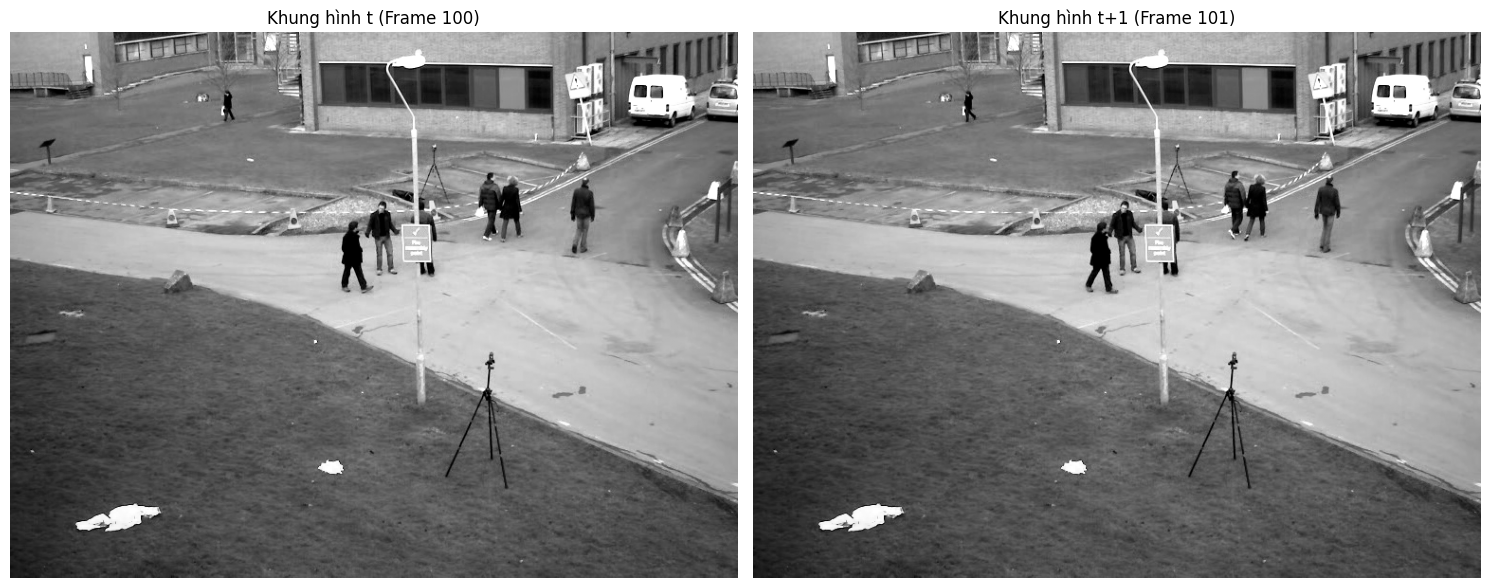

In [85]:
if len(frames) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Hiển thị Khung hình t (phần tử đầu tiên trong danh sách frames)
    axes[0].imshow(frames[0], cmap='gray')
    axes[0].set_title("Khung hình t (Frame 100)")
    axes[0].axis('off')

    # Hiển thị Khung hình t+1 (phần tử thứ hai trong danh sách frames)
    axes[1].imshow(frames[1], cmap='gray')
    axes[1].set_title("Khung hình t+1 (Frame 101)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Không đủ khung hình để hiển thị.")

## 2. Theo dõi điểm đặc trưng rời rạc (Sparse Optical Flow) với Lucas-Kanade

**Luồng quang học (Optical Flow)** là một trường vector biểu diễn sự dịch chuyển của điểm ảnh giữa các khung hình liên tiếp. Luồng quang học dựa trên một giả định cốt lõi: **Ràng buộc độ sáng không đổi (Brightness Constancy)**, tức là độ sáng của một điểm ảnh trên vật thể không thay đổi khi nó di chuyển qua khung hình tiếp theo.

Từ đó ta có phương trình: $I_x u + I_y v + I_t = 0$.
Tuy nhiên, đây là một **bài toán thiếu điều kiện (ill-posed problem)** vì ta có tới 2 ẩn số $(u, v)$ nhưng chỉ có 1 phương trình.

Thuật toán **Lucas-Kanade** giải quyết vấn đề này bằng một hướng tiếp cận cục bộ: Giả định rằng *tất cả các điểm ảnh trong một cửa sổ lân cận (ví dụ 3x3) đều có cùng một vector chuyển động*. Thuật toán sử dụng phương pháp Bình phương tối thiểu (Least Squares) để tìm ra vector $(u, v)$ tối ưu nhất.

### 2.1. Phát hiện các điểm góc tốt để theo dõi (Shi-Tomasi Corner Detector)

Phương pháp Lucas-Kanade cực kỳ nhanh nhưng có một điểm yếu chí mạng: **Bài toán khẩu độ (Aperture Problem)**. Nếu ta áp dụng nó lên một vùng ảnh trơn nhẵn hoặc chỉ có một đường biên thẳng, hệ phương trình sẽ bị suy biến và không thể xác định chính xác chuyển động.

Do đó, thuật toán Lucas-Kanade truyền thống không tính luồng quang cho toàn ảnh mà chỉ theo dõi các **"điểm đặc trưng rời rạc" (Sparse Optical Flow)**. Các điểm tốt nhất để theo dõi chính là **các góc (corners)** hoặc vùng có kết cấu (texture) mạnh đan chéo nhau.

Chúng ta sẽ dùng hàm `cv2.goodFeaturesToTrack` (dựa trên thuật toán Shi-Tomasi) để tìm ra các điểm này trên khung hình đầu tiên.

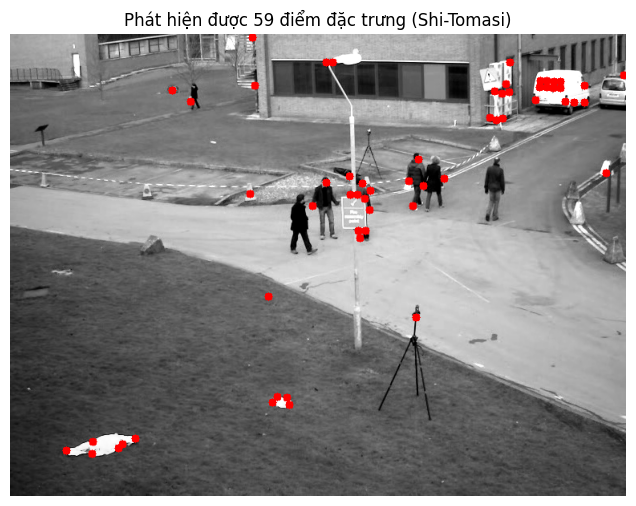

In [86]:
# Lấy khung hình đầu tiên và khung hình thứ hai từ danh sách đã trích xuất
old_gray = frames[0]
new_gray = frames[1]

# Cấu hình tham số cho thuật toán phát hiện góc Shi-Tomasi
feature_params = dict(
    maxCorners = 100,       # Lấy tối đa 100 điểm tốt nhất
    qualityLevel = 0.3,     # Chất lượng tối thiểu của điểm góc (0 -> 1)
    minDistance = 7,        # Khoảng cách tối thiểu giữa các góc (pixel)
    blockSize = 7           # Kích thước vùng lân cận để tính toán đạo hàm
)

# Tìm các điểm đặc trưng trên khung hình đầu tiên (old_gray)
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

# --- TRỰC QUAN HÓA CÁC ĐIỂM ĐẶC TRƯNG ---
# Tạo một bản sao có màu để vẽ các điểm góc lên cho dễ nhìn
old_frame_color = cv2.cvtColor(old_gray, cv2.COLOR_GRAY2BGR)

# Vẽ các điểm đã tìm được
if p0 is not None:
    for i in p0:
        x, y = i.ravel()
        # Vẽ vòng tròn đỏ, bán kính 5 pixel tại tọa độ (x,y)
        cv2.circle(old_frame_color, (int(x), int(y)), 5, (255, 0, 0), -1)

plt.figure(figsize=(10, 6))
plt.imshow(old_frame_color)
plt.title(f"Phát hiện được {len(p0)} điểm đặc trưng (Shi-Tomasi)")
plt.axis('off')
plt.show()

### 2.2. Áp dụng Lucas-Kanade tính toán sự dịch chuyển (Kim tự tháp ảnh - Pyramid)

Cơ chế cơ bản của Lucas-Kanade sử dụng khai triển Taylor và tính toán gia số để dò tìm chuyển động với độ chính xác đến từng pixel phụ (sub-pixel). Tuy nhiên, nó chỉ hoạt động tốt nếu đối tượng dịch chuyển **rất nhỏ** (1-2 pixel). Nếu đối tượng di chuyển quá nhanh, thuật toán sẽ thất bại.

Để giải quyết vấn đề chuyển động lớn, OpenCV tích hợp chiến lược **Từ thô đến tinh (Coarse-to-fine)** bằng cách xây dựng **Kim tự tháp ảnh (Image Pyramids)**.
Thuật toán sẽ bắt đầu tìm chuyển động ở ảnh bị thu nhỏ (nơi chuyển động lớn trở thành chuyển động nhỏ), sau đó phóng to vector tìm được để làm dự đoán ban đầu (seed) và tinh chỉnh dần ở ảnh gốc.

Chúng ta sử dụng hàm `cv2.calcOpticalFlowPyrLK` để thực hiện việc này.


In [87]:
# Cấu hình tham số cho thuật toán Lucas-Kanade
lk_params = dict(
    winSize  = (15, 15),    # Kích thước cửa sổ lân cận (patch)
    maxLevel = 2,           # Số tầng của Kim tự tháp ảnh (0 là chỉ dùng ảnh gốc)
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    # Tiêu chí dừng: lặp tối đa 10 lần hoặc sai số nhỏ hơn 0.03
)

# Tính toán Luồng quang học rời rạc
p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, new_gray, p0, None, **lk_params)

# Lọc ra những điểm theo dõi thành công
good_new = p1[st == 1]
good_old = p0[st == 1]

print(f"Tổng số điểm ban đầu: {len(p0)}")
print(f"Tổng số điểm bám vết thành công sang khung hình tiếp theo: {len(good_new)}")

# Tính toán vector vận tốc (dịch chuyển dx, dy) cho 5 điểm đầu tiên làm ví dụ
print("\nVí dụ vector dịch chuyển của 5 điểm đầu tiên:")
for i in range(min(5, len(good_new))):
    # good_new[i] là một mảng [x, y]
    dx = good_new[i][0] - good_old[i][0]
    dy = good_new[i][1] - good_old[i][1]
    print(f"Điểm {i+1}: dx = {dx:.2f} pixels, dy = {dy:.2f} pixels")

Tổng số điểm ban đầu: 59
Tổng số điểm bám vết thành công sang khung hình tiếp theo: 59

Ví dụ vector dịch chuyển của 5 điểm đầu tiên:
Điểm 1: dx = 0.39 pixels, dy = 0.04 pixels
Điểm 2: dx = -0.00 pixels, dy = -0.00 pixels
Điểm 3: dx = 0.00 pixels, dy = 0.00 pixels
Điểm 4: dx = 0.00 pixels, dy = 0.00 pixels
Điểm 5: dx = 0.00 pixels, dy = 0.00 pixels


### 2.3. Vẽ quỹ đạo (Trajectory) của các điểm đang di chuyển lên Video

Ở bước 2.2, chúng ta chỉ mới tính toán sự dịch chuyển qua **2 khung hình riêng lẻ**. Để thấy rõ sức mạnh của Lucas-Kanade, chúng ta cần đưa nó vào một vòng lặp (loop) chạy qua liên tiếp nhiều khung hình của video.

**Kỹ thuật vẽ quỹ đạo:**
Thay vì chỉ vẽ vị trí hiện tại của điểm, chúng ta sẽ lưu lại lịch sử di chuyển. Để làm được điều này một cách tối ưu, ta tạo ra một **bức ảnh mặt nạ (mask)** màu đen trống rỗng cùng kích thước với video ban đầu. Ở mỗi khung hình, ta sẽ vẽ một đoạn thẳng nối vị trí cũ ($p_0$) và vị trí mới ($p_1$) lên mask. Cuối cùng, dùng hàm `cv2.add()` để chập mặt nạ này vào khung hình hiện tại.

Thuật toán này thường được gọi là bộ bám vết KLT (Kanade-Lucas-Tomasi) tracker.

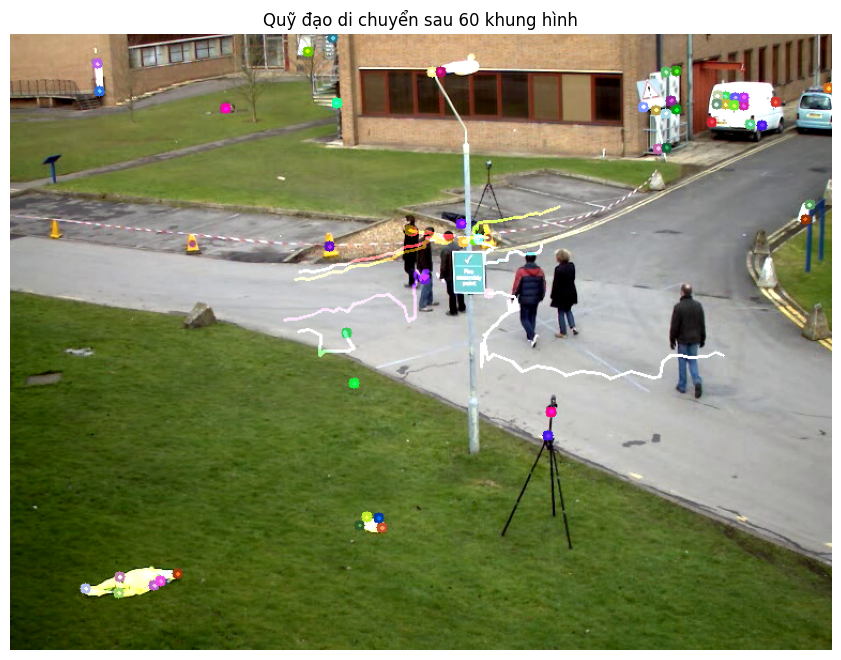

In [88]:
# Mở lại video để đọc từ đầu
cap = cv2.VideoCapture(video_path)

# 1. Đọc khung hình đầu tiên và tìm các điểm đặc trưng
ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

# Tạo một mask trống (ảnh toàn màu đen) để vẽ quỹ đạo (lines)
mask = np.zeros_like(old_frame)

# Tạo mảng màu ngẫu nhiên để vẽ mỗi quỹ đạo một màu khác nhau cho dễ phân biệt
color = np.random.randint(0, 255, (100, 3))

# Danh sách lưu các khung hình kết quả để hiển thị sau (nếu chạy trên Colab/Jupyter)
output_frames = []
frame_limit = 60 # Chỉ lấy 60 frame để demo nhanh

count = 0
while cap.isOpened() and count < frame_limit:
    ret, frame = cap.read()
    if not ret:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 2. Tính toán Optical Flow bằng Lucas-Kanade
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

    # Nếu không tìm thấy điểm nào, thoát vòng lặp
    if p1 is None:
        break

    # 3. Lọc ra các điểm bám vết thành công (status = 1)
    good_new = p1[st == 1]
    good_old = p0[st == 1]

    # 4. Vẽ quỹ đạo
    for i, (new, old) in enumerate(zip(good_new, good_old)):
        a, b = new.ravel() # Tọa độ x, y mới
        c, d = old.ravel() # Tọa độ x, y cũ

        # Ép kiểu sang int để vẽ
        a, b, c, d = int(a), int(b), int(c), int(d)

        # Vẽ đường thẳng nối điểm cũ và mới trên mask
        mask = cv2.line(mask, (a, b), (c, d), color[i].tolist(), 2)
        # Vẽ điểm tròn tại vị trí hiện tại trên frame
        frame = cv2.circle(frame, (a, b), 5, color[i].tolist(), -1)

    # Gộp ảnh frame hiện tại và mask quỹ đạo
    img_output = cv2.add(frame, mask)
    output_frames.append(cv2.cvtColor(img_output, cv2.COLOR_BGR2RGB))

    # 5. Cập nhật lại dữ liệu cho vòng lặp tiếp theo
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2) # Reshape lại đúng định dạng của OpenCV

    count += 1

cap.release()

# --- Hiển thị frame cuối cùng của chuỗi quỹ đạo ---
plt.figure(figsize=(12, 8))
plt.imshow(output_frames[-1])
plt.title(f"Quỹ đạo di chuyển sau {count} khung hình")
plt.axis('off')
plt.show()

### 2.4. Thảo luận: Quan sát hiện tượng mất dấu (Tracking loss)

Khi chạy đoạn code trên trên các video thực tế dài hơn, các bạn sẽ sớm nhận ra số lượng quỹ đạo (lines) ngày càng giảm đi, tức là các điểm đặc trưng bị "rụng" hoặc bị bám sai mục tiêu. Tại sao phương pháp Lucas-Kanade lại bị mất dấu?

Nguyên nhân xuất phát từ chính các **ràng buộc toán học** cốt lõi của thuật toán:

1.  **Bài toán Khẩu độ (Aperture Problem):** Thuật toán giải hệ phương trình bằng một cửa sổ cục bộ nhỏ. Nếu trong quá trình di chuyển, điểm đặc trưng đi vào một vùng trơn nhẵn (không có kết cấu) hoặc trượt dọc theo một đoạn biên thẳng dài, ma trận tính toán sẽ bị suy biến. Máy tính sẽ không thể xác định được chuyển động dọc theo đường biên đó.
2.  **Giới hạn về Ràng buộc độ sáng (Brightness Constancy):** Lucas-Kanade giả định chặt chẽ rằng cường độ sáng của một điểm ảnh là bất biến ($I_x u + I_y v + I_t = 0$). Trong thực tế, khi đối tượng di chuyển qua vùng có bóng râm, thay đổi góc chiếu sáng hoặc bị một vật thể khác **che khuất (occlusions)**, phương trình này bị phá vỡ hoàn toàn và thuật toán mất dấu.
3.  **Chuyển động quá lớn hoặc đột ngột:** Mặc dù đã dùng chiến lược "Kim tự tháp ảnh" (Pyramid) để thu nhỏ chuyển động từ thô đến tinh, nhưng nếu vật thể bị rung lắc quá giật cục hoặc dịch chuyển một khoảng quá xa chỉ trong 1 frame, đạo hàm Taylor bậc 1 xấp xỉ bị sai lệch, dẫn tới thuật toán phân kì.

**💡 Giải pháp trong thực tiễn:**
Để hệ thống không bị "cạn kiệt" điểm theo dõi, trong các ứng dụng thực tế (như SLAM hoặc Ổn định video), người ta không bao giờ chỉ dùng một tập `p0` ban đầu. Thay vào đó, sau mỗi $N$ khung hình (ví dụ mỗi 10 frames), người ta sẽ gọi lại hàm `cv2.goodFeaturesToTrack()` để **bổ sung thêm** các điểm đặc trưng mới cho những vùng chưa có điểm theo dõi.

## 3. Luồng quang học dày đặc (Dense Optical Flow) với thuật toán Farneback

Ở phần trước, chúng ta đã thấy thuật toán Lucas-Kanade cực kỳ nhanh nhưng chỉ tính toán được Luồng quang học rời rạc (Sparse Optical Flow) tại các điểm góc có kết cấu mạnh. Nếu chúng ta muốn biết MỌI điểm ảnh trong bức hình đang di chuyển về đâu (ví dụ: dòng nước chảy, lá rụng, hay hình nền bị nhòe), chúng ta cần một phương pháp **Luồng quang học dày đặc (Dense Optical Flow)**.

Phương pháp này sẽ trả về một trường vector dày đặc cho mọi pixel, nghĩa là với một ảnh đầu vào kích thước $H \times W$, kết quả ta nhận được sẽ là một tensor 3 chiều kích thước $(H, W, 2)$, chứa 2 kênh đại diện cho vận tốc dịch chuyển dọc và ngang $(u, v)$ của từng điểm ảnh.

Trong bài thực hành này, chúng ta sẽ sử dụng hàm `cv2.calcOpticalFlowFarneback()`. Thuật toán này do Gunnar Farneback đề xuất năm 2003, sử dụng khai triển đa thức để xấp xỉ các vùng lân cận của điểm ảnh, từ đó ước lượng luồng quang học một cách mượt mà và chính xác.

### 3.1. Tính toán vector vận tốc (u, v) cho mọi điểm ảnh

Chúng ta sẽ bắt đầu bằng việc trích xuất lại 2 khung hình liên tiếp từ video, chuyển sang ảnh xám và đưa vào hàm của OpenCV.

Hàm `cv2.calcOpticalFlowFarneback` nhận vào một số tham số quan trọng mà các bạn cần lưu ý để tinh chỉnh độ chính xác và tốc độ:
*   `pyr_scale`: Tỷ lệ thu nhỏ để tạo Kim tự tháp ảnh (thường là 0.5 - tức là mỗi tầng thu nhỏ một nửa).
*   `levels`: Số tầng của kim tự tháp (ví dụ: 3). Giúp bắt được các chuyển động lớn.
*   `winsize`: Kích thước cửa sổ trung bình. Cửa sổ càng lớn thì thuật toán càng chịu nhiễu tốt nhưng lại dễ làm mờ các chi tiết chuyển động nhỏ cục bộ.
*   `iterations`: Số lần lặp tìm kiếm ở mỗi tầng.
*   `poly_n`, `poly_sigma`: Các tham số dùng để khai triển đa thức làm mượt ảnh.

In [89]:
# Lấy lại 2 khung hình đầu tiên để minh họa
# Giả sử chúng ta sử dụng lại hàm extract_grayscale_frames đã viết ở phần 1
frames = extract_grayscale_frames(video_path, start_frame=150, num_frames=2, stride=1)

# Lấy từng khung hình cụ thể từ danh sách
frame1 = frames[0]
frame2 = frames[1]

# Tính toán Dense Optical Flow bằng thuật toán Farneback
# Các tham số: prev, next, flow, pyr_scale, levels, winsize, iterations, poly_n, poly_sigma, flags
flow = cv2.calcOpticalFlowFarneback(
    prev=frame1,
    next=frame2,
    flow=None,
    pyr_scale=0.5,
    levels=3,
    winsize=15,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
) # Cấu hình tham số chuẩn tham khảo từ tài liệu

print("Kích thước của ảnh gốc:", frame1.shape)
print("Kích thước của ma trận Optical Flow:", flow.shape)
print("Ma trận Flow có 2 kênh đại diện cho vận tốc (dx, dy) hay (u, v) của từng pixel.")

Kích thước của ảnh gốc: (576, 768)
Kích thước của ma trận Optical Flow: (576, 768, 2)
Ma trận Flow có 2 kênh đại diện cho vận tốc (dx, dy) hay (u, v) của từng pixel.


### 3.2. Chuyển đổi ma trận vector $(u, v)$ sang tọa độ cực (Magnitude, Angle)

Đầu ra của hàm trên là một ma trận chứa hai kênh $(u, v)$, biểu diễn vận tốc di chuyển theo trục ngang (trục x) và trục dọc (trục y). Tuy nhiên, những con số nguyên thủy này rất khó để máy tính có thể trực quan hóa trực tiếp thành hình ảnh để con người quan sát.

Để giải quyết vấn đề này, chúng ta cần biến đổi ma trận vector $(u, v)$ trong hệ tọa độ Descartes (Cartesian) sang **Hệ tọa độ Cực (Polar coordinates)**.
Hệ tọa độ cực sẽ biểu diễn vector dưới dạng 2 thành phần:
1.  **Độ lớn (Magnitude):** Chiều dài của vector, cho biết điểm ảnh di chuyển *nhanh* hay *chậm*.
2.  **Góc (Angle):** Hướng của vector, cho biết điểm ảnh di chuyển về *hướng nào*.

OpenCV cung cấp hàm `cv2.cartToPolar()` để làm việc này một cách tối ưu trên toàn bộ ma trận điểm ảnh.

In [90]:
# Tách 2 kênh u (dx) và v (dy) từ ma trận flow
u = flow[..., 0]
v = flow[..., 1]

# Chuyển đổi từ tọa độ Descartes (Cartesian) sang tọa độ Cực (Polar)
# angleInDegrees=True để lấy góc theo độ (0-360) thay vì radian cho dễ xử lý sau này
mag, ang = cv2.cartToPolar(u, v, angleInDegrees=True)

print("Kích thước ma trận Độ lớn (Magnitude):", mag.shape)
print("Kích thước ma trận Góc (Angle):", ang.shape)

# Hiển thị thống kê nhanh
print(f"\nVận tốc dịch chuyển lớn nhất trong khung hình: {np.max(mag):.2f} pixels")
print(f"Vận tốc dịch chuyển trung bình: {np.mean(mag):.2f} pixels")

Kích thước ma trận Độ lớn (Magnitude): (576, 768)
Kích thước ma trận Góc (Angle): (576, 768)

Vận tốc dịch chuyển lớn nhất trong khung hình: 12.36 pixels
Vận tốc dịch chuyển trung bình: 0.17 pixels


### 3.3. Trực quan hóa Luồng quang học bằng không gian màu HSV

Đầu ra của Luồng quang học Farneback là một ma trận chứa 2 kênh $(u, v)$, rất khó có thể quan sát trực tiếp bằng mắt thường. Ở bước 3.2, chúng ta đã chuyển đổi nó thành Độ lớn (Magnitude) và Góc (Angle).

Để hiển thị trực quan nhất, chúng ta sẽ sử dụng kỹ thuật **Mã hóa bằng Màu sắc (Color Encoding) thông qua không gian màu HSV**. Không gian HSV (Hue - Saturation - Value) rất phù hợp với dữ liệu tọa độ cực vì:
*   **Kênh H (Hue - Sắc độ):** Tương ứng với **Góc (Angle)**. Màu sắc sẽ cho chúng ta biết điểm ảnh đang di chuyển về hướng nào (Ví dụ: đi sang phải có thể là màu đỏ, đi lên trên là màu xanh lam).
*   **Kênh V (Value - Độ sáng) hoặc S (Saturation - Độ bão hòa):** Tương ứng với **Độ lớn (Magnitude)**. Vận tốc di chuyển càng nhanh thì màu sắc sẽ càng sáng và đậm; ngược lại, vùng đứng im (vận tốc = 0) sẽ có màu đen.

Dưới đây, chúng ta sẽ tạo một bức ảnh HSV trống, gán các giá trị từ `mag` và `ang` vào, sau đó chuyển đổi về hệ RGB để quan sát.

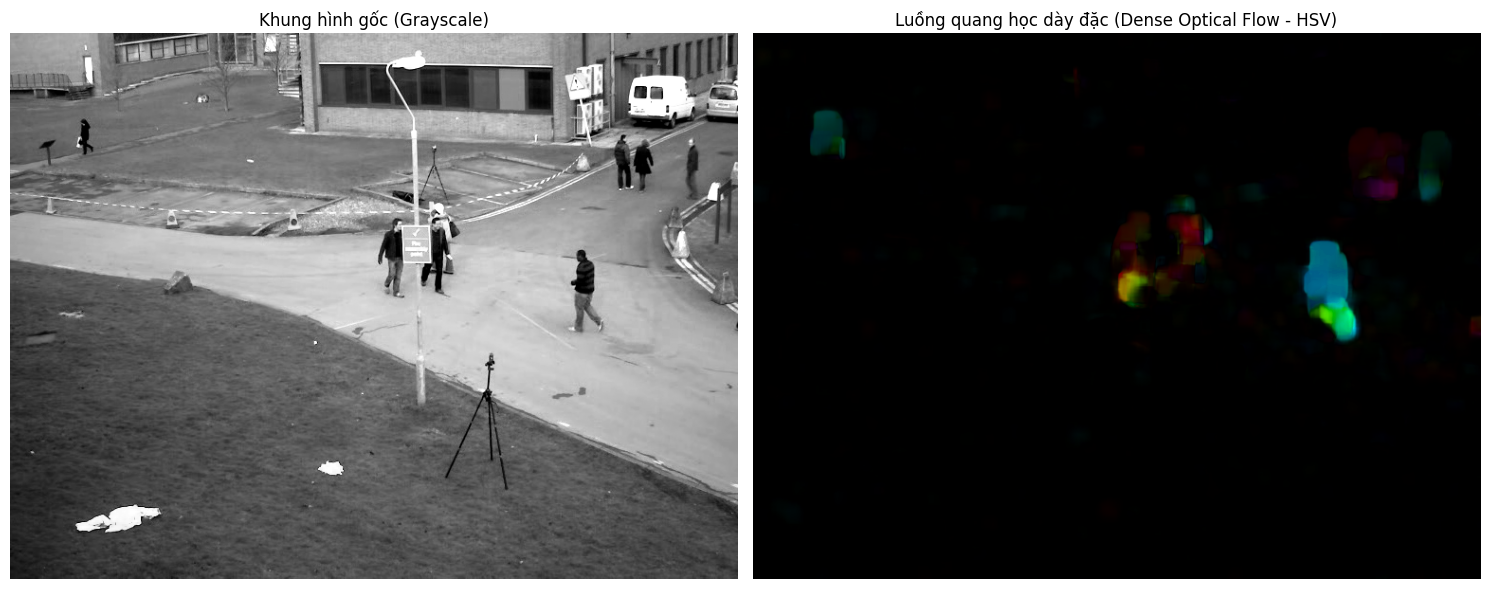

In [91]:
# 1. Tạo một ma trận ảnh HSV trống có cùng chiều cao và chiều rộng với ảnh gốc, gồm 3 kênh màu
# Kiểu dữ liệu uint8 (0-255) là chuẩn định dạng ảnh của OpenCV
hsv = np.zeros((*frame1.shape, 3), dtype=np.uint8)

# 2. Kênh S (Saturation - Độ bão hòa):
# Đặt tất cả bằng 255 (mức tối đa) để màu sắc hiển thị rực rỡ nhất có thể
hsv[..., 1] = 255

# 3. Kênh H (Hue - Sắc độ): Biểu diễn Hướng di chuyển
# Lưu ý: Mảng 'ang' hiện đang có giá trị từ 0-360 độ.
# Tuy nhiên, trong OpenCV kiểu uint8, kênh H chỉ nhận giá trị từ 0-179.
# Do đó, ta cần chia mảng ang cho 2.
hsv[..., 0] = ang / 2

# 4. Kênh V (Value - Độ sáng): Biểu diễn Vận tốc
# Hàm cv2.normalize sẽ tự động kéo giãn các giá trị của 'mag' (từ min đến max)
# trải đều ra khoảng 0-255 để thể hiện độ sáng.
hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

# 5. Chuyển đổi hệ màu từ HSV sang RGB để hiển thị đúng bằng Matplotlib
rgb_optical_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

# --- HIỂN THỊ KẾT QUẢ SO SÁNH ---
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Hiển thị ảnh gốc (Khung hình 1)
axes[0].imshow(frame1, cmap='gray')
axes[0].set_title("Khung hình gốc (Grayscale)")
axes[0].axis('off')

# Hiển thị ảnh Luồng quang học
axes[1].imshow(rgb_optical_flow)
axes[1].set_title("Luồng quang học dày đặc (Dense Optical Flow - HSV)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

**💡 Cách đọc hiểu bức ảnh Luồng quang học (HSV):**
*   **Vùng màu đen:** Những khu vực này có Độ sáng (Value) bằng 0, nghĩa là `mag = 0`. Điều này cho thấy nền (background) hoặc các vật thể ở vùng đó **đứng yên**.
*   **Vùng có màu sắc:** Thể hiện các đối tượng đang **di chuyển**.
*   **Cường độ sáng:** Màu càng rực và sáng nghĩa là vật thể di chuyển càng nhanh. Lớp màu mờ hoặc nhòe ở viền thường là do hiện tượng che khuất hoặc bóng đổ.
*   **Sự khác biệt màu sắc:** Nếu hai chiếc xe đi ngược chiều nhau trên đường, chúng sẽ được hiển thị bằng hai màu hoàn toàn đối lập nhau trên vòng tròn màu Hue (ví dụ: xe đi sang trái có màu lục, xe đi sang phải có màu hồng/đỏ).

### 3.4. So sánh sự khác biệt giữa Sparse (Lucas-Kanade) và Dense (Farneback)

Sau khi đã tự tay lập trình cả hai thuật toán, chúng ta hãy cùng nhìn lại và so sánh bản chất của hai cách tiếp cận này để biết khi nào nên sử dụng công cụ nào trong thực tế:

**1. Lucas-Kanade (Tiếp cận Cục bộ - Sparse Optical Flow):**
*   **Cơ chế:** Giải phương trình ràng buộc độ sáng bằng cách xét một cửa sổ lân cận cục bộ, giả định các điểm ảnh trong cửa sổ có cùng vận tốc di chuyển.
*   **Ưu điểm:** Tính toán cực kỳ nhanh, hội tụ tốt tại các điểm có kết cấu mạnh (texture) như góc hoặc cạnh. Rất phù hợp cho các bài toán bám vết điểm rời rạc (Tracking) hoặc Ổn định video (Video Stabilization) bằng phương pháp tịnh tiến/Affine.
*   **Nhược điểm:** Mắc phải **"Bài toán khẩu độ" (Aperture problem)**. Thuật toán hoàn toàn thất bại và không thể tính toán được luồng quang học ở những vùng ảnh trơn nhẵn hoặc chỉ có một đường biên thẳng.

**2. Farneback / Horn-Schunck (Tiếp cận Dày đặc - Dense Optical Flow):**
*   **Cơ chế:** Tính toán trường vector vận tốc cho **mọi** điểm ảnh. Thuật toán Farneback sử dụng khai triển đa thức để xấp xỉ sự biến đổi của các vùng lân cận điểm ảnh, trong khi Horn-Schunck sử dụng ràng buộc độ trơn toàn cục (Global Smoothness) để lan truyền chuyển động.
*   **Ưu điểm:** Cung cấp thông tin chuyển động chi tiết của toàn bộ bối cảnh. Giải quyết được điểm yếu của Lucas-Kanade tại các vùng ảnh trơn nhẵn. Phù hợp cho bài toán phân tích hành động (Action Recognition), tách nền động, hoặc làm đầu vào cho các mạng Deep Learning.
*   **Nhược điểm:** Chi phí tính toán cao hơn rất nhiều. Ràng buộc độ trơn đôi khi có xu hướng làm mờ đi ranh giới chuyển động giữa các vật thể với nhau.

### 3.5. Thực hành: Viết vòng lặp chạy Dense Optical Flow trên toàn bộ Video

Giống như những gì đã làm với Lucas-Kanade ở phần 2, bây giờ chúng ta sẽ đưa hàm `cv2.calcOpticalFlowFarneback` vào trong một vòng lặp `while` để đọc video từng khung hình một.

Đoạn code dưới đây sẽ liên tục tính toán luồng quang học giữa khung hình hiện tại và khung hình ngay trước nó, sau đó mã hóa thành ảnh màu HSV và lưu lại thành một chuỗi (sequence) để chúng ta có thể xem như một đoạn video chuyển động đầy màu sắc.

Bắt đầu xử lý Dense Optical Flow. Vui lòng đợi...
Đã xử lý xong 60 khung hình!


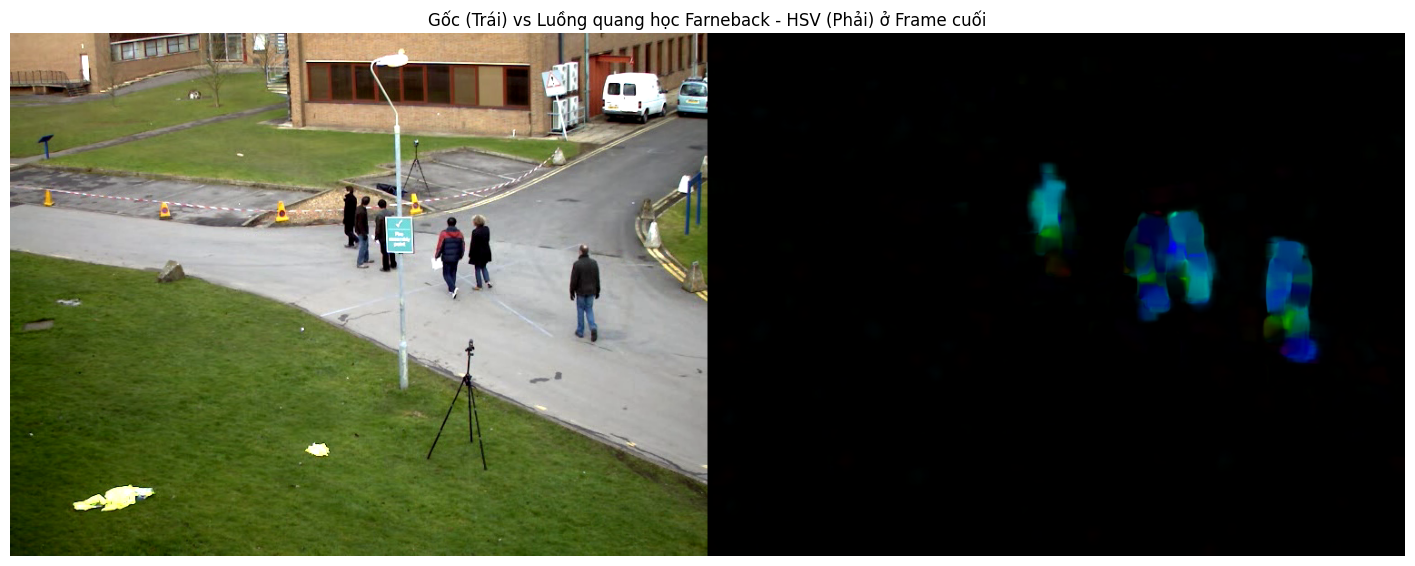

In [92]:
# Mở lại luồng video
cap = cv2.VideoCapture(video_path)

# Đọc khung hình đầu tiên làm mốc (t=0)
ret, frame1 = cap.read()
prvs = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)

# Tạo một ma trận HSV trống tái sử dụng cho mọi khung hình để tối ưu bộ nhớ
hsv = np.zeros_like(frame1)
hsv[..., 1] = 255 # Đặt độ bão hòa (Saturation) ở mức tối đa

output_dense_frames = []
frame_limit = 60 # Giới hạn số lượng frame để notebook không bị quá tải bộ nhớ
count = 0

print("Bắt đầu xử lý Dense Optical Flow. Vui lòng đợi...")

while(cap.isOpened() and count < frame_limit):
    ret, frame2 = cap.read()
    if not ret:
        break

    next_frame = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    # 1. Tính toán Dense Optical Flow
    flow = cv2.calcOpticalFlowFarneback(prvs, next_frame, None, 0.5, 3, 15, 3, 5, 1.2, 0)

    # 2. Chuyển sang tọa độ Cực (Magnitude, Angle)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1], angleInDegrees=True)

    # 3. Ánh xạ sang hệ màu HSV
    hsv[..., 0] = ang / 2
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

    # 4. Chuyển đổi về RGB để lưu và hiển thị bằng Matplotlib
    rgb_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

    # Nối khung hình gốc và khung hình Flow cạnh nhau để dễ so sánh
    frame2_rgb = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)
    combined_img = np.hstack((frame2_rgb, rgb_flow))

    output_dense_frames.append(combined_img)

    # 5. Cập nhật khung hình hiện tại thành khung hình "cũ" cho vòng lặp tiếp theo
    prvs = next_frame
    count += 1

cap.release()
print(f"Đã xử lý xong {count} khung hình!")

# --- HIỂN THỊ KẾT QUẢ KHUNG HÌNH CUỐI CÙNG ---
if len(output_dense_frames) > 0:
    plt.figure(figsize=(18, 7))
    plt.imshow(output_dense_frames[-1])
    plt.title("Gốc (Trái) vs Luồng quang học Farneback - HSV (Phải) ở Frame cuối")
    plt.axis('off')
    plt.show()

## 4. Ước lượng Chuyển động Tham số (Parametric Motion: Affine & Homography)

Đến lúc này, chúng ta đã tìm hiểu hai cách tiếp cận:
1.  **Mô hình tịnh tiến cục bộ (Lucas-Kanade):** Chỉ mô tả được sự dịch chuyển phẳng ngang/dọc (2 Bậc tự do - DoF) của từng điểm riêng lẻ.
2.  **Luồng quang học dày đặc (Farneback):** Tính toán vận tốc cho mọi điểm ảnh, nhưng tốn kém tài nguyên và dễ bị nhiễu.

**Thực tế hình ảnh:** Camera trong không gian thực thường quét (pan), nghiêng (tilt), thu phóng (zoom) hoặc xoay quanh trục. Đối với những chuyển động camera này, toàn bộ khung hình sẽ di chuyển theo một quy luật hình học chung.

Thay vì tính chuyển động cho từng điểm ảnh, ta có thể dùng **Chuyển động tham số toàn cục (Global Parametric Motion)**: Sử dụng một ma trận toán học chứa một vài tham số để chi phối sự dịch chuyển của toàn bộ bức ảnh. Hai mô hình phổ biến nhất là:
*   **Biến đổi Affine (6 DoF):** Bao gồm Tịnh tiến, Xoay, Thu phóng và Kéo xô. Nó bảo toàn tính song song của các đường thẳng.
*   **Biến đổi Homography (8 DoF - Phối cảnh):** Biểu diễn chính xác sự thay đổi góc nhìn camera 3D đối với một mặt phẳng. Nó làm biến dạng góc nhìn và không bảo toàn tính song song. Mô hình này cực kỳ hiệu quả để ứng dụng trong Ổn định video (Video Stabilization) hoặc Khâu ảnh Panorama (Image Stitching).

### 4.1. Trích xuất và so khớp đặc trưng cục bộ (SIFT + FLANN)

Để tìm được ma trận chuyển động toàn cục giữa khung hình $t$ và $t+1$, chúng ta cần tìm ra các "điểm neo" (control points) đáng tin cậy giữa hai ảnh.

Khác với Lucas-Kanade chỉ theo dõi các góc nhỏ ở khoảng cách gần, chúng ta sẽ sử dụng các bộ trích xuất đặc trưng mạnh mẽ như **SIFT (Scale-Invariant Feature Transform)**. SIFT là "tiêu chuẩn vàng" vì nó có khả năng bất biến với tỷ lệ (scale), phép xoay (rotation) và thay đổi độ sáng.

Quy trình thực hiện:
1.  Trích xuất các keypoints và vector đặc trưng (128 chiều) bằng SIFT trên cả 2 khung hình.
2.  Sử dụng thư viện **FLANN** (Fast Library for Approximate Nearest Neighbors) để tìm kiếm các cặp điểm giống nhau nhất giữa 2 khung hình.
3.  Áp dụng **Kiểm tra tỷ lệ của Lowe (Lowe's ratio test)** để loại bỏ các điểm so khớp sai (outliers). Tiêu chí này so sánh khoảng cách của điểm giống nhất với điểm giống thứ hai để đảm bảo độ tin cậy.

Số lượng điểm SIFT trên ảnh 1: 1543
Số lượng điểm SIFT trên ảnh 2: 1566
Số lượng cặp điểm so khớp tốt (Good matches): 810


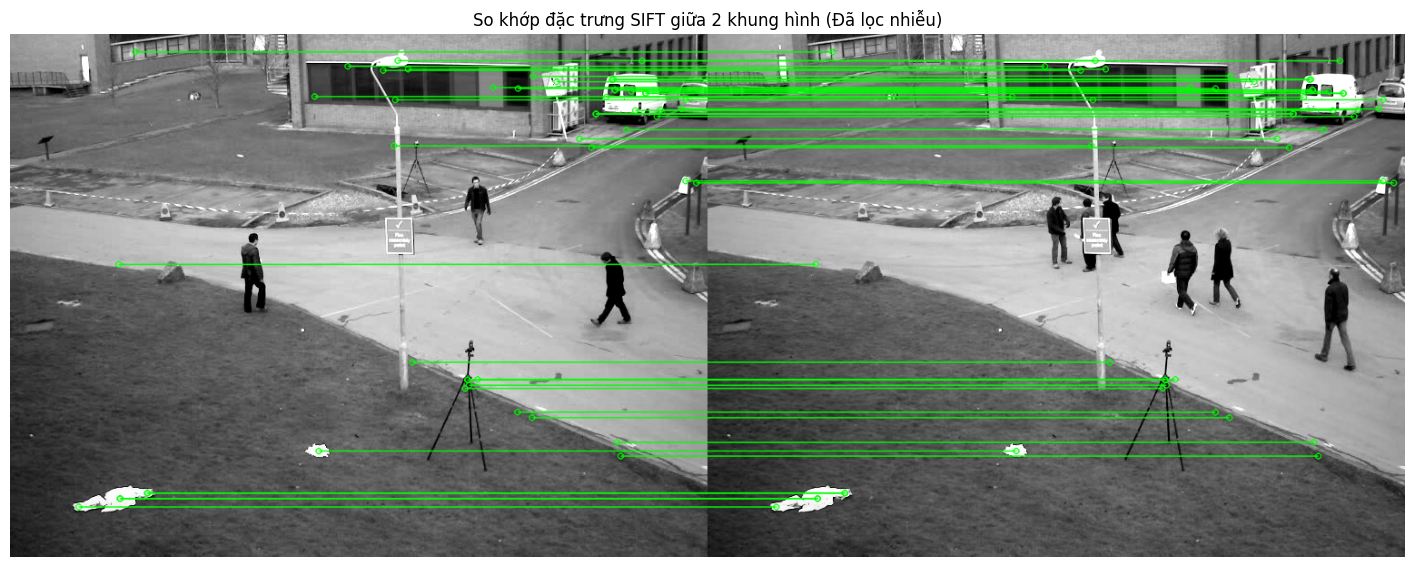

In [93]:
# Để thấy rõ sự biến đổi không gian (phối cảnh/affine), chúng ta sẽ lấy 2 khung hình
# cách nhau một khoảng thời gian (ví dụ: frame 0 và frame 50) thay vì 2 frame liên tiếp.
frames_parametric = extract_grayscale_frames(video_path, start_frame=0, num_frames=2, stride=50)

if len(frames_parametric) == 2:
    # Lấy từng khung hình cụ thể từ danh sách
    img1 = frames_parametric[0] # Khung hình t
    img2 = frames_parametric[1] # Khung hình t+50

    # 1. Khởi tạo bộ tách đặc trưng SIFT
    sift = cv2.SIFT_create()

    # Tìm Keypoints (kp) và Descriptors (des) cho cả hai ảnh
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    print(f"Số lượng điểm SIFT trên ảnh 1: {len(kp1)}")
    print(f"Số lượng điểm SIFT trên ảnh 2: {len(kp2)}")

    # 2. Khởi tạo bộ so khớp FLANN
    # Thuật toán KDTree (algorithm=1) hoạt động rất nhanh và tối ưu cho SIFT
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    search_params = dict(checks = 50) # Số lần kiểm tra (càng cao càng chính xác nhưng chậm)

    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # Tìm 2 láng giềng gần nhất (k=2) cho mỗi điểm đặc trưng
    matches = flann.knnMatch(des1, des2, k=2)

    # 3. Lọc nhiễu bằng Lowe's Ratio Test
    good_matches = []
    for m, n in matches:
        # Nếu khoảng cách của điểm giống nhất (m) nhỏ hơn 70% khoảng cách của điểm giống thứ nhì (n)
        # thì đó là một cặp so khớp thực sự chất lượng
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)

    print(f"Số lượng cặp điểm so khớp tốt (Good matches): {len(good_matches)}")

    # --- TRỰC QUAN HÓA KẾT QUẢ SO KHÓP ---
    # Chỉ vẽ 50 điểm tốt nhất để hình đỡ bị rối
    good_matches = sorted(good_matches, key = lambda x:x.distance)
    img_matches = cv2.drawMatches(
        img1, kp1, img2, kp2, good_matches[:50], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        matchColor=(0, 255, 0) # Vẽ các đường nối màu xanh lá
    )

    plt.figure(figsize=(18, 8))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title("So khớp đặc trưng SIFT giữa 2 khung hình (Đã lọc nhiễu)")
    plt.axis('off')
    plt.show()

else:
    print("Vui lòng kiểm tra lại đường dẫn video hoặc hàm trích xuất.")

**💡 Quan sát và Thảo luận:**
Mặc dù chúng ta đã sử dụng tỷ lệ Lowe để lọc bớt các điểm so khớp sai (outliers), nhưng nếu bạn nhìn kỹ vào bức ảnh trên, vẫn có thể sót lại một vài đường thẳng chéo nhau một cách vô lý.

Những điểm lỗi này sẽ làm sai lệch nghiêm trọng toán học khi ta giải hệ phương trình tìm ma trận biến đổi (Homography/Affine). Đó là lý do ở bước tiếp theo, chúng ta **không bao giờ** dùng tất cả các điểm này một cách trực tiếp, mà phải thông qua một thuật toán "cứu cánh" có tên là **RANSAC**.

### 4.2. Tính toán ma trận biến đổi (Affine/Homography) với RANSAC

Ở bước 4.1, SIFT và FLANN đã giúp chúng ta tìm được các cặp điểm có vẻ "giống nhau" nhất. Tuy nhiên, dù đã lọc bằng tỷ lệ Lowe, kết quả vẫn luôn chứa những điểm so khớp sai (outliers) do sự trùng lặp kết cấu hoặc nhiễu. Nếu dùng trực tiếp tất cả các điểm này để giải phương trình tìm ma trận chuyển động (Least Squares), kết quả sẽ bị sai lệch hoàn toàn.

Để giải quyết vấn đề này, chúng ta sử dụng thuật toán **RANSAC (RANdom SAmple Consensus)**.
*   RANSAC hoạt động bằng cách chọn ngẫu nhiên một tập hợp con nhỏ nhất các điểm cần thiết để ước lượng mô hình (ví dụ: cần 4 cặp điểm cho Homography), sau đó tính toán ra một ma trận giả định.
*   Tiếp theo, thuật toán sẽ đo lường xem có bao nhiêu cặp điểm còn lại trong tập dữ liệu "đồng thuận" (nằm trong ngưỡng sai số cho phép) với ma trận giả định đó,. Những điểm đồng thuận này gọi là **inliers**.
*   Quá trình được lặp lại nhiều lần, và ma trận nào thu hút được số lượng inliers lớn nhất sẽ được chọn làm kết quả cuối cùng.

**Lựa chọn Mô hình chuyển động:**
*   **Biến đổi Affine:** Sử dụng ma trận có 6 bậc tự do (6 DoF), bao gồm các phép tịnh tiến, xoay, thu phóng và kéo xô, bảo toàn tính song song của đường thẳng.
*   **Biến đổi Homography (Phối cảnh):** Sử dụng ma trận $3 \times 3$ với 8 bậc tự do (8 DoF) hoạt động trên hệ tọa độ đồng nhất, giúp biểu diễn chính xác sự thay đổi góc nhìn camera 3D đối với một mặt phẳng.

Trong bài thực hành này, ta sẽ dùng hàm `cv2.findHomography` kết hợp cờ `cv2.RANSAC` để tính toán ma trận phối cảnh $H$.

--- TÍNH TOÁN MA TRẬN HOMOGRAPHY THÀNH CÔNG ---
Ma trận biến đổi H (3x3):
[[ 1.0003e+00  1.0000e-04 -3.3000e-02]
 [ 0.0000e+00  1.0003e+00 -2.4000e-02]
 [ 0.0000e+00  0.0000e+00  1.0000e+00]]

Số lượng điểm Inliers (Đồng thuận): 799 / 810 (98.6%)


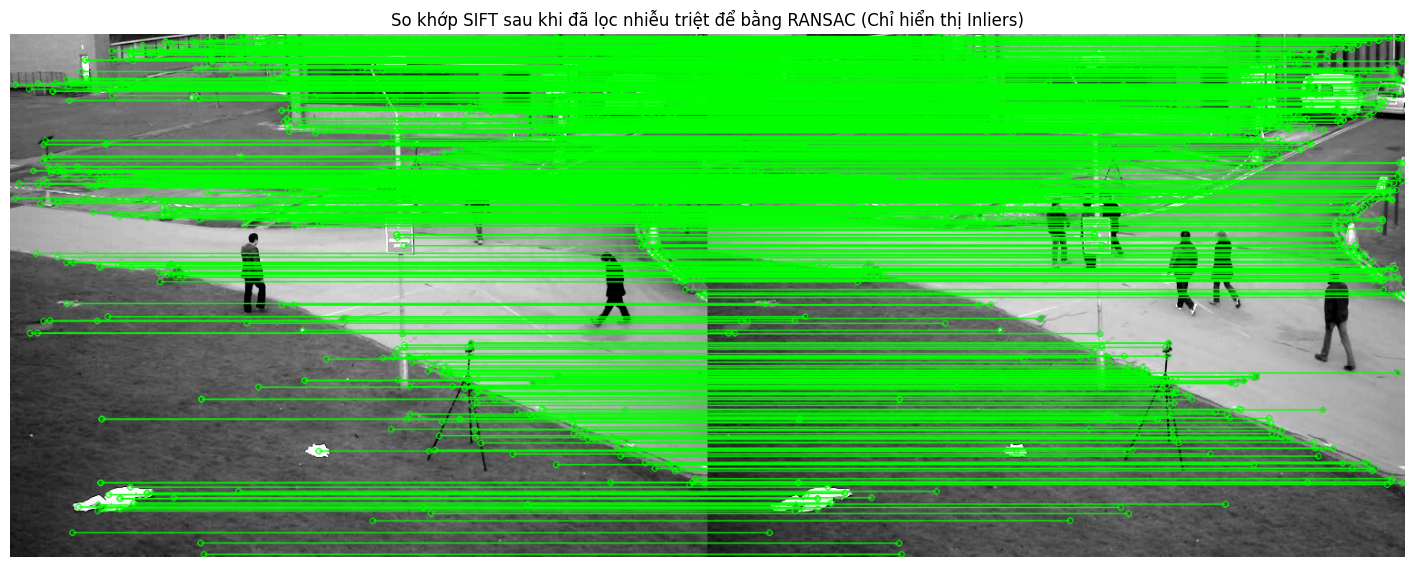

In [94]:
# Chỉ tiến hành tính toán nếu tìm được đủ số điểm tối thiểu
# Cần ít nhất 4 điểm để giải hệ phương trình Homography (8 DoF)
MIN_MATCH_COUNT = 10

if len(good_matches) > MIN_MATCH_COUNT:
    # 1. Trích xuất tọa độ (x, y) của các điểm so khớp tốt từ 2 khung hình
    # Cấu trúc lại mảng thành định dạng float32 mà OpenCV yêu cầu: (N, 1, 2)
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

    # 2. Tính toán ma trận Homography (H) với RANSAC
    # Tham số 5.0 là ngưỡng sai số (pixel) để RANSAC phân loại một điểm là inlier hay outlier
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # mask là một mảng nhị phân (1 = inlier, 0 = outlier)
    matchesMask = mask.ravel().tolist()

    print("--- TÍNH TOÁN MA TRẬN HOMOGRAPHY THÀNH CÔNG ---")
    print("Ma trận biến đổi H (3x3):")
    print(np.round(H, 4))

    inlier_count = np.sum(matchesMask)
    print(f"\nSố lượng điểm Inliers (Đồng thuận): {inlier_count} / {len(good_matches)} "
          f"({inlier_count/len(good_matches)*100:.1f}%)")

    # 3. Vẽ lại các cặp điểm so khớp, nhưng chỉ vẽ các Inliers (loại bỏ Outliers)
    draw_params = dict(matchColor = (0, 255, 0), # Inliers vẽ màu xanh lá
                       singlePointColor = None,
                       matchesMask = matchesMask, # Áp dụng mặt nạ RANSAC
                       flags = 2)

    img_inliers = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, **draw_params)

    plt.figure(figsize=(18, 8))
    plt.imshow(cv2.cvtColor(img_inliers, cv2.COLOR_BGR2RGB))
    plt.title("So khớp SIFT sau khi đã lọc nhiễu triệt để bằng RANSAC (Chỉ hiển thị Inliers)")
    plt.axis('off')
    plt.show()

else:
    print(f"Không đủ số lượng điểm so khớp - Cần ít nhất {MIN_MATCH_COUNT}, nhưng chỉ có {len(good_matches)}")
    matchesMask = None

**💡 Thảo luận & Phân tích:**
Hãy nhìn vào hình ảnh đầu ra và so sánh nó với kết quả ở bước 4.1. Bạn sẽ thấy tất cả các đường chéo nhau lộn xộn (những điểm mà SIFT ghép sai) đã bị biến mất. Chỉ còn lại các đường thẳng song song hoặc đồng nhất hướng về một phía.

Điều này chứng tỏ RANSAC đã "hiểu" được dòng chảy chuyển động chung của cả khung hình (Global Motion) và thành công cô lập/loại bỏ những điểm ảnh di chuyển bất thường hoặc bị nhiễu. Ma trận $H$ thu được chính là "chiếc chìa khóa" toán học mô tả toàn bộ sự thay đổi góc nhìn camera giữa khung hình $t$ và $t+1$.

### 4.3. Ứng dụng biến đổi ảnh (`cv2.warpPerspective`) để dóng hàng khung hình

Ở bước 4.2, chúng ta đã tìm được ma trận Homography $H$ ($3 \times 3$, 8 bậc tự do). Ma trận này mô tả chính xác cách góc nhìn camera thay đổi giữa khung hình $t$ (`img1`) và $t+50$ (`img2`). Vì tập `src_pts` được lấy từ `img1` và `dst_pts` lấy từ `img2`, ma trận $H$ sẽ dùng để ánh xạ (map) các tọa độ từ `img1` sang hệ tọa độ của `img2`.

Bây giờ, chúng ta sẽ sử dụng hàm `cv2.warpPerspective` của OpenCV. Hàm này sẽ lấy từng điểm ảnh của `img1`, nhân tọa độ của nó với ma trận $H$, và "bẻ cong" bức ảnh đó để khớp hoàn toàn với phối cảnh của `img2`.

Kỹ thuật này chính là cốt lõi của hai ứng dụng cực kỳ phổ biến trong Thị giác máy tính:
1. **Khâu ảnh toàn cảnh (Panorama / Image Stitching):** Dóng hàng các bức ảnh chụp ở các góc khác nhau rồi ghép lại.
2. **Ổn định Video (Video Stabilization):** Tìm ma trận bù trừ rung lắc và dóng hàng các frame về một mốc tọa độ cố định để triệt tiêu chuyển động của camera.

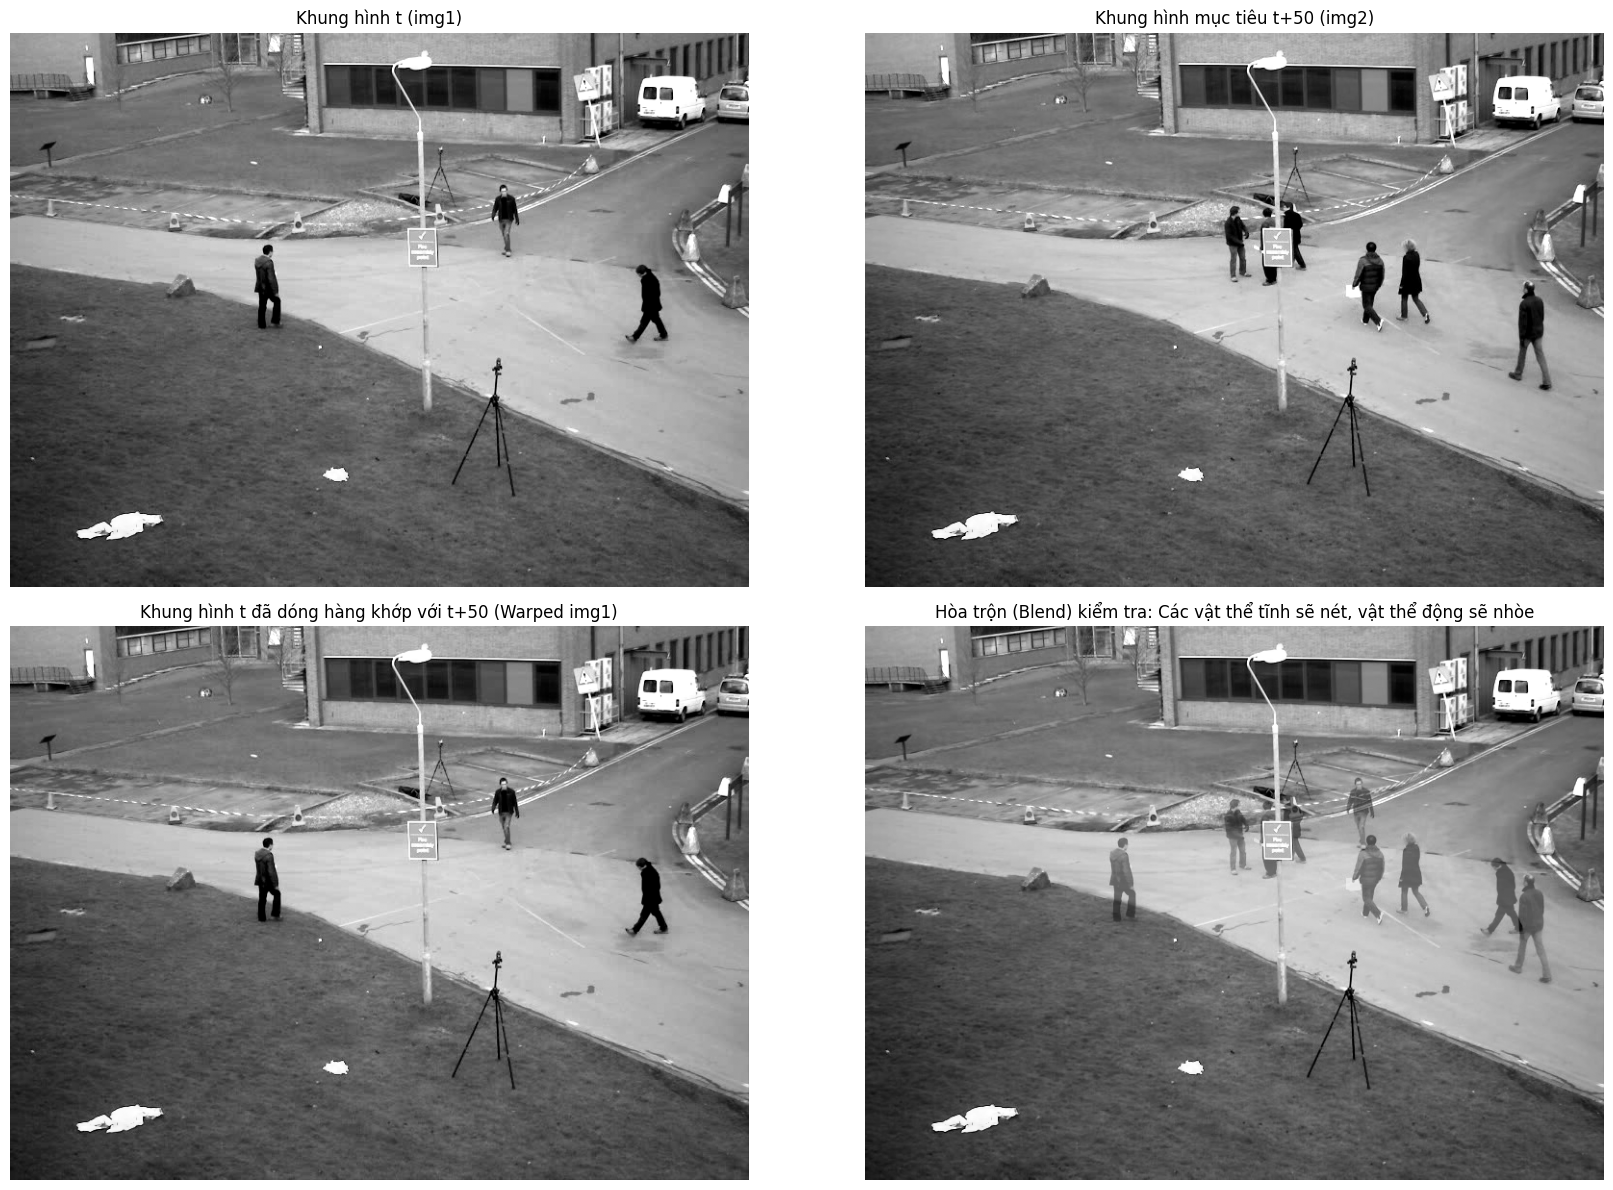

In [95]:
if matchesMask is not None and H is not None:
    # Lấy kích thước của khung hình đích (img2) để làm khung chứa
    height, width = img2.shape

    # Thực hiện biến đổi phối cảnh (Warping) cho img1 bằng ma trận H
    # Kết quả img1_aligned sẽ có góc nhìn và vị trí khớp với img2
    img1_aligned = cv2.warpPerspective(img1, H, (width, height))

    # --- TRỰC QUAN HÓA KẾT QUẢ QUÁ TRÌNH DÓNG HÀNG ---
    # axes sẽ là một mảng 2x2
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # 1. Khung hình gốc t
    axes[0, 0].imshow(img1, cmap='gray')
    axes[0, 0].set_title("Khung hình t (img1)")
    axes[0, 0].axis('off')

    # 2. Khung hình mục tiêu t+50
    axes[0, 1].imshow(img2, cmap='gray')
    axes[0, 1].set_title("Khung hình mục tiêu t+50 (img2)")
    axes[0, 1].axis('off')

    # 3. Khung hình t sau khi đã được dóng hàng (Warped)
    axes[1, 0].imshow(img1_aligned, cmap='gray')
    axes[1, 0].set_title("Khung hình t đã dóng hàng khớp với t+50 (Warped img1)")
    axes[1, 0].axis('off')

    # 4. Chập 2 ảnh (Blended) để kiểm tra độ khớp
    # Dùng cv2.addWeighted để hòa trộn img2 và img1_aligned với tỷ lệ 50-50
    blended_img = cv2.addWeighted(img2, 0.5, img1_aligned, 0.5, 0)
    axes[1, 1].imshow(blended_img, cmap='gray')
    axes[1, 1].set_title("Hòa trộn (Blend) kiểm tra: Các vật thể tĩnh sẽ nét, vật thể động sẽ nhòe")
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Không có ma trận H để thực hiện biến đổi.")

**💡 Thảo luận: Phân tích kết quả Dóng hàng (Alignment Analysis)**

1. **Hiệu ứng Bóng ma (Ghosting / Parallax):**
   Khi nhìn vào bức ảnh hòa trộn (Blend) ở góc dưới bên phải, bạn sẽ thấy nền đường, các tòa nhà tĩnh hoặc vạch kẻ đường trùng khớp hoàn hảo (rất sắc nét). Tuy nhiên, những chiếc xe đang di chuyển sẽ tạo ra hiệu ứng "bóng ma" (xuất hiện 2 hình mờ mờ).
   *Lý do:* Ma trận Homography chỉ bắt được **chuyển động nền toàn cục (Global Background Motion)** do camera gây ra. Nó không thể (và cũng không có nhiệm vụ) dóng hàng các đối tượng tiền cảnh di chuyển độc lập.

2. **Các vùng khuyết đen (Missing Borders / Artifacts):**
   Ở bức ảnh `Warped img1`, bạn sẽ thấy xuất hiện các viền đen ở rìa ảnh.
   *Tại sao lại có hiện tượng này?* Khi bức ảnh bị dịch chuyển, xoay hoặc thu phóng để bù trừ chuyển động, một số phần của ảnh gốc sẽ bị đẩy ra ngoài khung hình, đồng thời để lại những khoảng trống không có dữ liệu ở rìa.
   *Giải pháp trong thực tế:* Để xử lý các viền đen này trong các phần mềm Ổn định Video (như Premiere Pro, CapCut hay Google Photos), người ta thường dùng kỹ thuật **Phóng to (Zoom-in)** cắt bỏ phần viền, hoặc dùng AI nội suy lấp đầy (Inpainting) các điểm ảnh bị khuyết.

## 5. Ứng dụng thực tiễn: Ổn định Video (Video Stabilization) cơ bản

Trong thực tế, khi quay video bằng điện thoại cầm tay hoặc camera hành trình (dashcam), hình ảnh thu được thường bị rung lắc ngẫu nhiên (camera shake). Mục tiêu của thuật toán Ổn định Video là loại bỏ những rung lắc tần số cao không mong muốn này, đồng thời giữ lại các chuyển động quét/xoay có chủ ý của người quay (chuyển động tần số thấp),.

Một pipeline (quy trình) ổn định video tiêu chuẩn thường trải qua 3 giai đoạn:
1. **Giai đoạn 1 - Ước lượng chuyển động:** Tìm chuyển động nền (background motion) giữa các khung hình liên tiếp để xây dựng quỹ đạo di chuyển của camera.
2. **Giai đoạn 2 - Làm mượt chuyển động:** Áp dụng bộ lọc (như trung bình trượt - Moving Average) để tạo ra một quỹ đạo "ảo" mượt mà hơn.
3. **Giai đoạn 3 - Biến đổi ảnh (Warping):** Bù trừ chuyển động và cắt xén viền để kết xuất video cuối cùng,.

Trong phần này, chúng ta sẽ xây dựng một bộ ổn định video cơ bản từ con số 0!

### 5.1. Tính toán chuyển động nền toàn cục (Background Motion)

Nhiệm vụ đầu tiên của chúng ta là phải biết camera đã bị rung lắc như thế nào qua từng khung hình.

**Thách thức:** Thuật toán phải "khóa" (lock) đúng vào chuyển động của phông nền do camera tạo ra, chứ không bị đánh lừa bởi các vật thể tiền cảnh (như người, xe cộ) đang di chuyển độc lập trong video,.
**Giải pháp:** Chúng ta sẽ sử dụng bộ theo dõi `Lucas-Kanade` để bám vết các điểm đặc trưng, sau đó dùng RANSAC để loại bỏ các điểm nhiễu (thuộc về vật thể chuyển động).

*Lưu ý về Mô hình chuyển động:* Thay vì dùng ma trận Homography (8 DoF) dễ bị tích lũy sai số gây biến dạng hình học khi áp dụng cho video dài, các hệ thống ổn định video thường ưu tiên sử dụng **mô hình Similarity hoặc Rigid (Affine một phần)** bao gồm Tịnh tiến, Xoay và Thu phóng,. Trong bài này, ta sẽ dùng hàm `cv2.estimateAffinePartial2D` (trả về ma trận $2 \times 3$).

In [102]:
import numpy as np
import cv2
import os

shaky_video_path = 'shaky_video.avi'

# 1. Kiểm tra sự tồn tại của file
if not os.path.exists(shaky_video_path) or os.path.getsize(shaky_video_path) == 0:
    print(f"Lỗi: Không tìm thấy file {shaky_video_path} hoặc file bị rỗng.")
else:
    cap = cv2.VideoCapture(shaky_video_path)

    # 2. Đếm số khung hình (metadata hoặc manual)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if n_frames <= 0:
        print("Đang đếm khung hình thủ công...")
        count = 0
        while True:
            ret, frame = cap.read()
            if not ret: break
            count += 1
        n_frames = count
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    print(f"Thông tin Video: {n_frames} khung hình.")

    if n_frames <= 1:
        print("Lỗi: Video không có đủ dữ liệu.")
    else:
        # 3. Khởi tạo mảng lưu trữ
        transforms = np.zeros((n_frames - 1, 3), np.float32)

        ret, prev = cap.read()
        if not ret:
            print("Lỗi: Không thể đọc khung hình đầu tiên.")
        else:
            prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)
            print("Bắt đầu tính toán chuyển động. Vui lòng đợi...")

            for i in range(n_frames - 1):
                # Tìm điểm đặc trưng
                prev_pts = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01, minDistance=30, blockSize=3)

                ret, curr = cap.read()
                if not ret: break
                curr_gray = cv2.cvtColor(curr, cv2.COLOR_BGR2GRAY)

                # Optical Flow
                curr_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None)

                if curr_pts is not None and len(curr_pts) > 0:
                    idx = np.where(status == 1)[0]
                    if len(idx) > 0:
                        # Ước lượng chuyển động Affine
                        m, _ = cv2.estimateAffinePartial2D(prev_pts[idx], curr_pts[idx], method=cv2.RANSAC)
                        if m is not None:
                            dx, dy = m[0, 2], m[1, 2]
                            da = np.arctan2(m[1, 0], m[0, 0])
                            transforms[i] = [dx, dy, da]

                prev_gray = curr_gray
                if i % 100 == 0: print(f"Đã xử lý frame {i}/{n_frames-1}")

            cap.release()
            print(f"Hoàn tất! Biến 'transforms' đã được tạo với {len(transforms)} bản ghi.")

Thông tin Video: 795 khung hình.
Bắt đầu tính toán chuyển động. Vui lòng đợi...
Đã xử lý frame 0/794
Đã xử lý frame 100/794
Đã xử lý frame 200/794
Đã xử lý frame 300/794
Đã xử lý frame 400/794
Đã xử lý frame 500/794
Đã xử lý frame 600/794
Đã xử lý frame 700/794
Hoàn tất! Biến 'transforms' đã được tạo với 794 bản ghi.


In [103]:
import requests
import os

# Sử dụng link từ kho lưu trữ chính thức của OpenCV
video_url = 'https://github.com/opencv/opencv/raw/master/samples/data/vtest.avi'
video_filename = 'shaky_video.avi'

def download_video(url, filename):
    try:
        print(f"Đang tải video mẫu từ OpenCV: {url}...")
        response = requests.get(url, stream=True, timeout=30)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                for chunk in response.iter_content(chunk_size=1024*1024):
                    if chunk:
                        f.write(chunk)
            print(f"Tải xuống thành công: {filename} ({os.path.getsize(filename)} bytes)")
            return True
        else:
            print(f"Lỗi: Mã trạng thái {response.status_code}")
            return False
    except Exception as e:
        print(f"Lỗi kết nối: {e}")
        return False

# Dọn dẹp file cũ
if os.path.exists(video_filename):
    os.remove(video_filename)

# Tiến hành tải mới
success = download_video(video_url, video_filename)
if success:
    print("Bây giờ bạn có thể chạy lại ô mã tính toán chuyển động bên dưới.")

Đang tải video mẫu từ OpenCV: https://github.com/opencv/opencv/raw/master/samples/data/vtest.avi...
Tải xuống thành công: shaky_video.avi (8131690 bytes)
Bây giờ bạn có thể chạy lại ô mã tính toán chuyển động bên dưới.


### Tích lũy biến đổi thành Quỹ đạo tuyệt đối (Absolute Trajectory)

Mảng `transforms` mà chúng ta vừa tính chỉ chứa độ dịch chuyển *tương đối* giữa 2 khung hình liền kề (ví dụ: từ frame 1 sang frame 2 lệch 3 pixels, từ frame 2 sang frame 3 lệch -1 pixel).

Để biết chính xác vị trí của camera ở khung hình thứ $t$ so với vị trí xuất phát ban đầu, chúng ta cần **cộng dồn (tích lũy)** các độ dịch chuyển này lại. Đây được gọi là **Quỹ đạo camera (Camera Trajectory)**. Chúng ta sẽ dùng hàm `np.cumsum()` (Cumulative Sum) của NumPy để tính toán nhanh.

Đồng thời, ta sẽ vẽ đồ thị quỹ đạo này ra để quan sát mức độ "rung lắc" của video gốc.

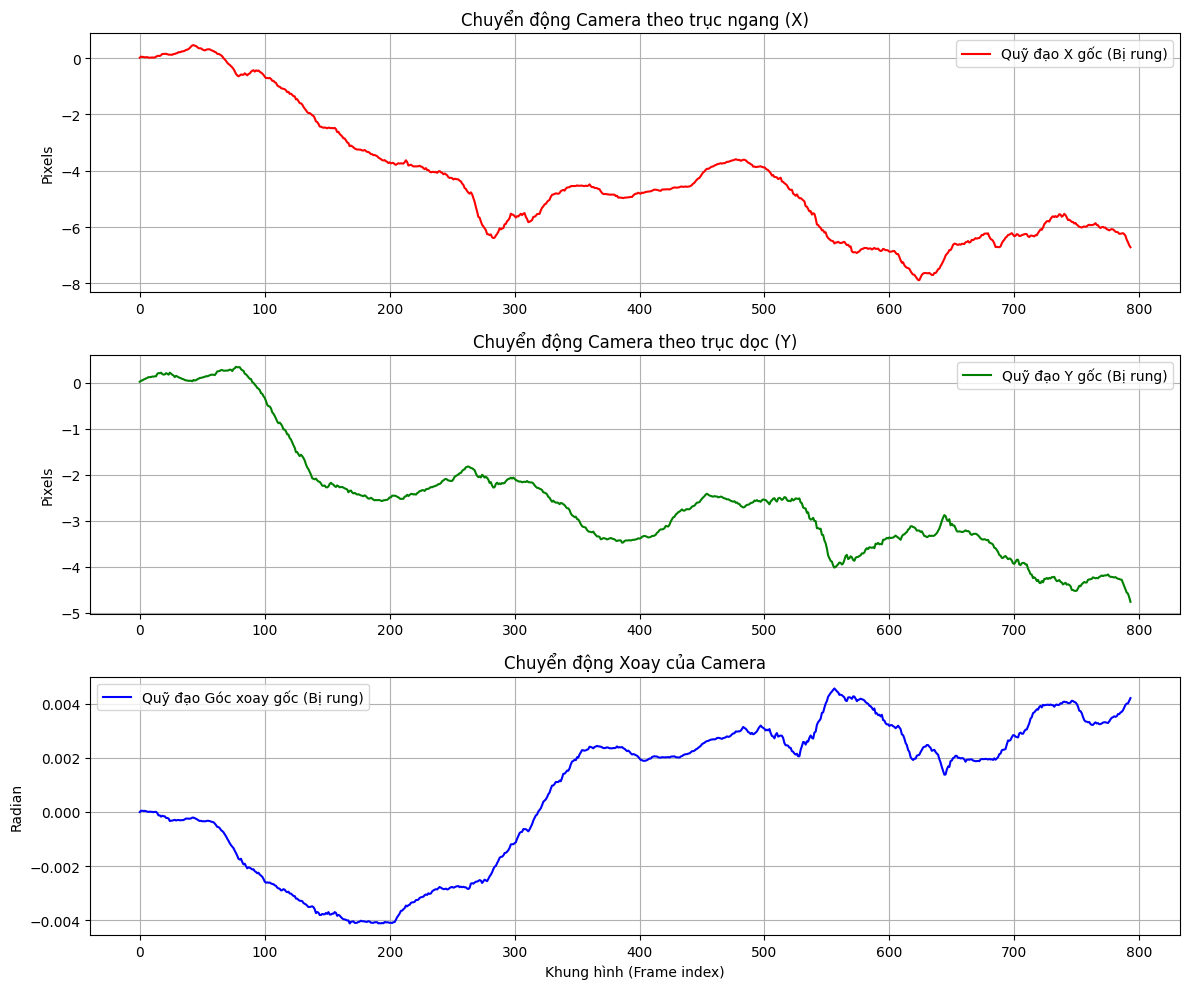

In [104]:
# Kiểm tra nếu transforms có dữ liệu mới vẽ đồ thị
if 'transforms' in locals() and len(transforms) > 0:
    # Tính toán Quỹ đạo tuyệt đối (tích lũy)
    trajectory = np.cumsum(transforms, axis=0)

    # Trích xuất X, Y, Angle
    x_trajectory = trajectory[:, 0]
    y_trajectory = trajectory[:, 1]
    a_trajectory = trajectory[:, 2]

    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    axes[0].plot(x_trajectory, label='Quỹ đạo X gốc (Bị rung)', color='red')
    axes[0].set_title('Chuyển động Camera theo trục ngang (X)')
    axes[0].set_ylabel('Pixels')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(y_trajectory, label='Quỹ đạo Y gốc (Bị rung)', color='green')
    axes[1].set_title('Chuyển động Camera theo trục dọc (Y)')
    axes[1].set_ylabel('Pixels')
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(a_trajectory, label='Quỹ đạo Góc xoay gốc (Bị rung)', color='blue')
    axes[2].set_title('Chuyển động Xoay của Camera')
    axes[2].set_ylabel('Radian')
    axes[2].set_xlabel('Khung hình (Frame index)')
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Cảnh báo: Biến 'transforms' đang rỗng. Hãy chạy lại ô mã phía trên trước.")

**💡 Quan sát Đồ thị:**
Bạn sẽ thấy đồ thị quỹ đạo di chuyển của camera (đường màu đỏ, xanh) có hình dạng nhấp nhô liên tục với các "gai" nhọn. Những đỉnh gai này chính là các nhiễu tần số cao (rung lắc tay). Nếu chúng ta dùng quỹ đạo này trực tiếp, video vẫn sẽ bị giật.

Nhiệm vụ ở phần tiếp theo là chúng ta phải "là phẳng" (smooth) những đường đồ thị này lại!

### 5.2. Làm mượt quỹ đạo (Motion Smoothing) bằng Trung bình trượt

Ở bước 5.1, chúng ta đã có được Quỹ đạo máy ảnh (Camera Trajectory) tuyệt đối. Quỹ đạo này bao gồm hai thành phần đan xen nhau:
1. **Tần số thấp (Low-frequency):** Chuyển động có chủ ý của người quay (ví dụ: lia máy sang trái, pan/tilt).
2. **Tần số cao (High-frequency):** Sự rung lắc ngẫu nhiên do tay cầm không chắc hoặc đi qua đường xóc (camera shake). Đây chính là phần chúng ta muốn triệt tiêu.

**Giải pháp:**
Để lọc bỏ tần số cao và giữ lại tần số thấp, một trong những phương pháp đơn giản và hiệu quả nhất là sử dụng bộ lọc **Trung bình trượt (Moving Average)**. Thuật toán sẽ trượt một "cửa sổ" (window) có kích thước $W$ qua mảng quỹ đạo, và thay thế giá trị tại điểm hiện tại bằng trung bình cộng của các điểm xung quanh nó.

Sau khi có được quỹ đạo trơn tru (Smoothed Trajectory), ta tính **độ lệch (Difference)** giữa quỹ đạo trơn tru và quỹ đạo gốc. Độ lệch này chính là "lượng rung lắc" cần được bù trừ vào các ma trận biến đổi (Transforms) ở từng khung hình.


In [106]:
SMOOTHING_RADIUS = 30 # Kích thước bán kính cửa sổ làm mượt (Window size = 2 * Radius + 1)

def moving_average(curve, radius):
    """Hàm tính trung bình trượt 1D bằng phép chập (Convolution)"""
    window_size = 2 * radius + 1

    # Tạo bộ lọc (filter) trung bình: một mảng toàn số 1 chia cho kích thước cửa sổ
    f = np.ones(window_size) / window_size

    # Pad (thêm viền) ở hai đầu mảng để giữ nguyên độ dài sau khi chập
    # Chế độ 'edge' sẽ lặp lại giá trị ở phần tử đầu/cuối
    curve_pad = np.pad(curve, (radius, radius), 'edge')

    # Áp dụng phép chập
    curve_smoothed = np.convolve(curve_pad, f, mode='same')

    # Cắt bỏ phần pad để trả về kích thước gốc
    curve_smoothed = curve_smoothed[radius:-radius]
    return curve_smoothed

def smooth_trajectory(trajectory, radius):
    """Hàm làm mượt quỹ đạo 3D (x, y, angle)"""
    smoothed_trajectory = np.copy(trajectory)
    # Lặp qua từng kênh độc lập (X, Y, Angle) và làm mượt
    for i in range(3):
        smoothed_trajectory[:,i] = moving_average(trajectory[:,i], radius)
    return smoothed_trajectory

# 1. Tính toán quỹ đạo đã làm mượt
smoothed_trajectory = smooth_trajectory(trajectory, SMOOTHING_RADIUS)

# 2. Tính toán lượng chênh lệch (độ rung lắc cần bù trừ)
# Độ lệch = Quỹ đạo mượt - Quỹ đạo gốc
difference = smoothed_trajectory - trajectory

# 3. Cập nhật lại mảng biến đổi khung hình (Transforms)
# Cộng phần bù trừ vào ma trận biến đổi tương đối frame-to-frame ban đầu
transforms_smooth = transforms + difference

print(f"Đã làm mượt quỹ đạo với bán kính {SMOOTHING_RADIUS} frames.")

Đã làm mượt quỹ đạo với bán kính 30 frames.


### Trực quan hóa Hiệu quả Làm mượt

Để chứng minh thuật toán Moving Average đã hoạt động đúng như kỳ vọng, chúng ta sẽ vẽ chồng quỹ đạo mới (màu đỏ - đã làm mượt) lên trên quỹ đạo gốc (màu xanh/mờ - bị rung lắc) từ phần 5.1.

Một quỹ đạo chuẩn xác sẽ bám theo xu hướng chung của đường gốc, nhưng "san phẳng" hoàn toàn các đỉnh gai nhọn.


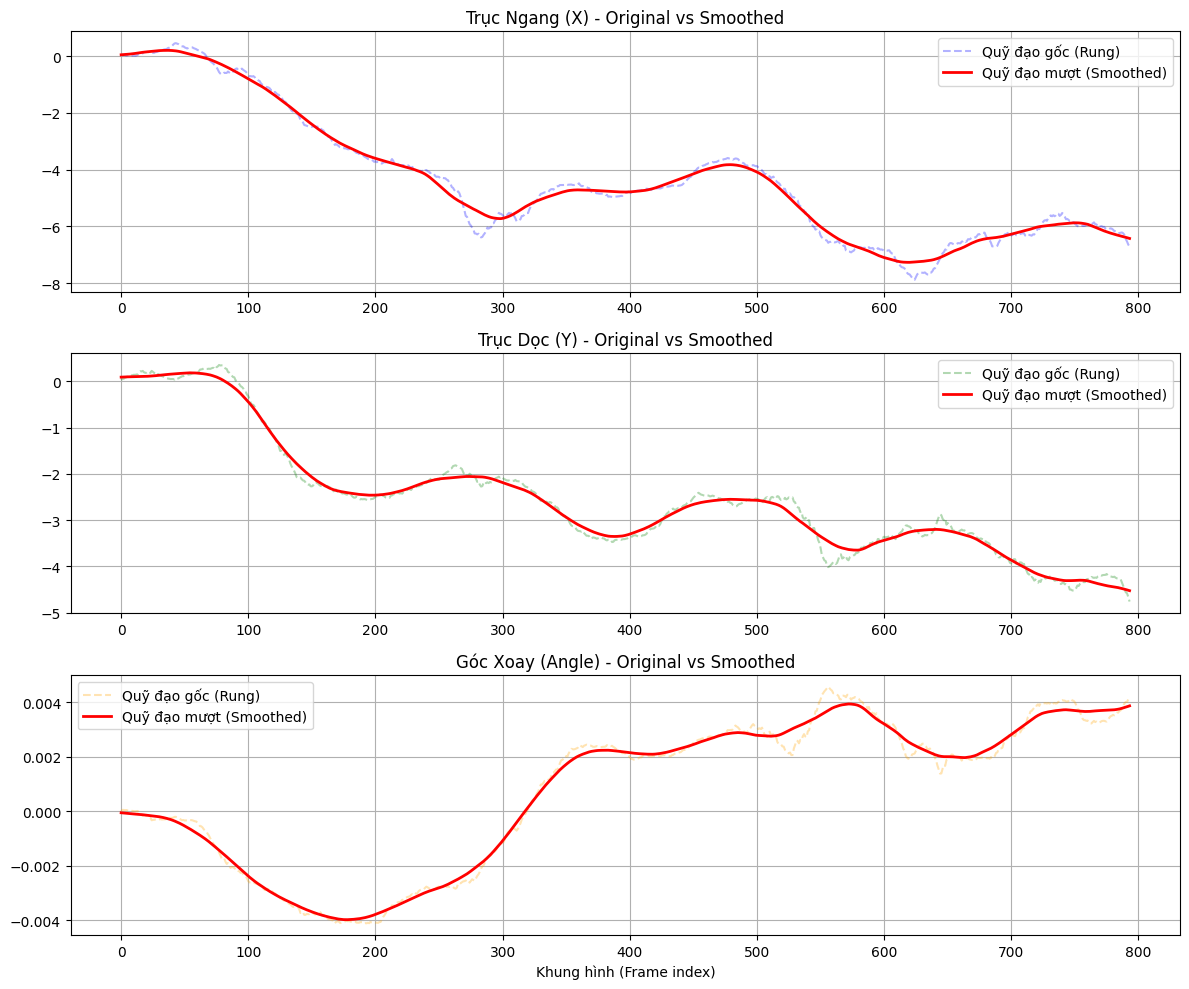

In [108]:
# Trích xuất dữ liệu để vẽ
x_smooth = smoothed_trajectory[:, 0]
y_smooth = smoothed_trajectory[:, 1]
a_smooth = smoothed_trajectory[:, 2]

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Đồ thị trục X
axes[0].plot(x_trajectory, label='Quỹ đạo gốc (Rung)', color='blue', alpha=0.3, linestyle='--')
axes[0].plot(x_smooth, label='Quỹ đạo mượt (Smoothed)', color='red', linewidth=2)
axes[0].set_title('Trục Ngang (X) - Original vs Smoothed')
axes[0].legend()
axes[0].grid(True)

# Đồ thị trục Y
axes[1].plot(y_trajectory, label='Quỹ đạo gốc (Rung)', color='green', alpha=0.3, linestyle='--')
axes[1].plot(y_smooth, label='Quỹ đạo mượt (Smoothed)', color='red', linewidth=2)
axes[1].set_title('Trục Dọc (Y) - Original vs Smoothed')
axes[1].legend()
axes[1].grid(True)

# Đồ thị Góc xoay (Angle)
axes[2].plot(a_trajectory, label='Quỹ đạo gốc (Rung)', color='orange', alpha=0.3, linestyle='--')
axes[2].plot(a_smooth, label='Quỹ đạo mượt (Smoothed)', color='red', linewidth=2)
axes[2].set_title('Góc Xoay (Angle) - Original vs Smoothed')
axes[2].set_xlabel('Khung hình (Frame index)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

**💡 Thảo luận:**
* Hãy thay đổi biến `SMOOTHING_RADIUS` (ví dụ: tăng lên 50, giảm xuống 10) và chạy lại các ô code trên. Bạn quan sát thấy hiện tượng gì?
* Nếu Radius quá nhỏ, video vẫn còn giật. Nhưng nếu Radius quá lớn (tiến tới bằng độ dài video), quỹ đạo mượt sẽ trở thành một đường thẳng tắp. Điều này có nghĩa là máy tính sẽ cố gắng ép camera đứng yên hoàn toàn, dẫn đến việc cắt mất quá nhiều viền ảnh ở các đoạn lia máy. Do đó, việc chọn cửa sổ làm mượt là sự đánh đổi giữa "độ mượt" và "diện tích hiển thị còn lại".

### 5.3. Bù trừ chuyển động và cắt viền (Crop/Zoom) để xử lý vùng biên bị khuyết

Ở bước 5.2, chúng ta đã tính được mảng `difference` chứa độ lệch giữa quỹ đạo trơn tru và quỹ đạo rung lắc gốc. Bây giờ, ở giai đoạn thứ 3 (Image Warping), chúng ta sẽ áp dụng các giá trị độ lệch $(dx, dy, d\theta)$ này ngược trở lại từng khung hình để "kéo" chúng về đúng vị trí mượt mà.

**Thách thức: Xử lý vùng biên bị khuyết (Missing Borders / Artifacts)**
Khi thuật toán dịch chuyển và xoay khung hình để bù trừ chuyển động, một số phần của bức ảnh sẽ bị đẩy ra ngoài khung hình, đồng thời để lộ ra các khoảng trống (viền màu đen) ở rìa ảnh.

**Giải pháp:**
*   **Phóng to (Zoom-in) & Cắt xén (Crop):** Chúng ta sẽ phóng to toàn bộ khung hình lên một tỷ lệ nhỏ (ví dụ 10%) xoay quanh tâm ảnh, sau đó cắt phần viền dư thừa. Kỹ thuật này sẽ lấp đầy các viền đen bị khuyết, đây cũng là cách đơn giản và phổ biến nhất được dùng trong các phần mềm chống rung.
*   *(Mở rộng - Inpainting):* Trong các hệ thống nâng cao, người ta có thể dùng AI để "ảo giác" (hallucinate) vẽ thêm các điểm ảnh bị thiếu ở viền, hoặc lấy điểm ảnh từ khung hình trước đó đắp vào.

Dưới đây, chúng ta sẽ lập trình phương pháp Zoom-in kết hợp với ma trận Affine.

Bắt đầu quá trình Warping bù trừ rung lắc. Vui lòng đợi...
Hoàn tất kết xuất 794 khung hình đã ổn định!


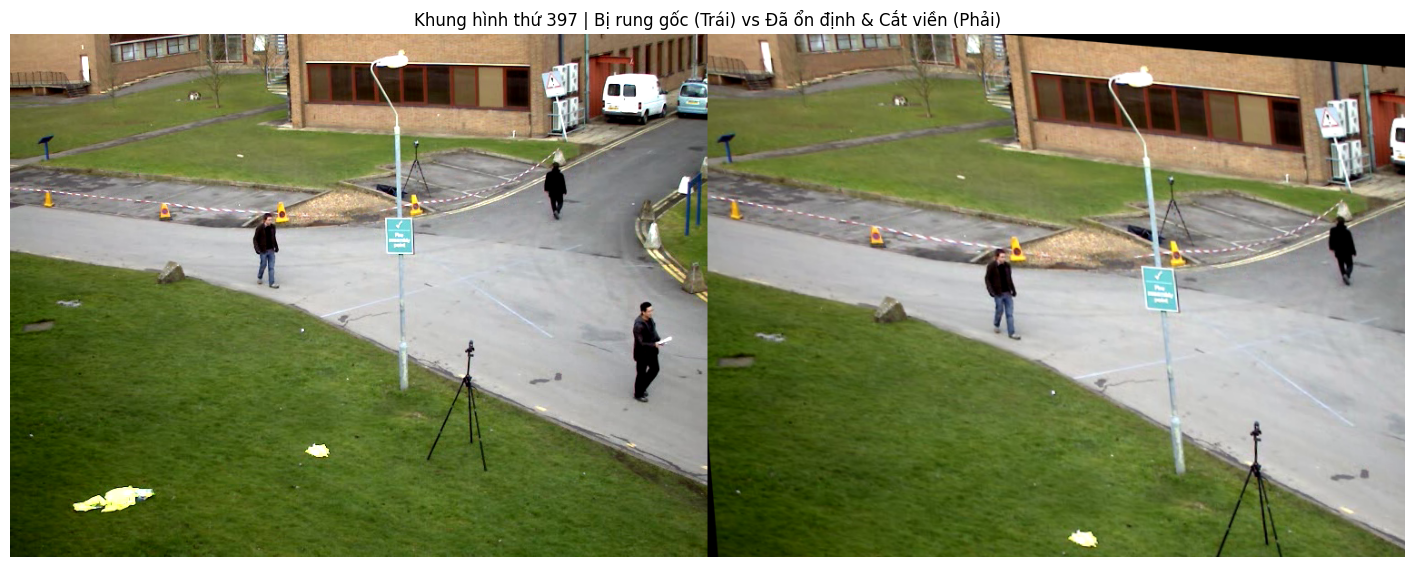

In [109]:
# Mở lại video gốc để tiến hành Warping
cap = cv2.VideoCapture(shaky_video_path)

# Lấy thông số cấu hình của video
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
center = (width // 2, height // 2)

# Thiết lập hệ số phóng to (Zoom) để giấu viền đen
ZOOM_FACTOR = 1.10 # Phóng to 10% (tùy thuộc vào mức độ rung của video gốc)

comparison_frames = [] # Lưu ảnh để hiển thị đối chiếu
count = 0

print("Bắt đầu quá trình Warping bù trừ rung lắc. Vui lòng đợi...")

while True:
    ret, frame = cap.read()
    # Dừng nếu hết video hoặc hết dữ liệu mảng độ lệch
    if not ret or count >= len(difference):
        break

    # Lấy các giá trị bù trừ từ mảng difference
    dx = difference[count, 0]
    dy = difference[count, 1]
    da = difference[count, 2] # Đơn vị radian

    # 1. Tạo ma trận biến đổi Affine
    # Hàm getRotationMatrix2D nhận góc xoay bằng độ (Degrees)
    angle_deg = da * 180 / np.pi

    # Tạo ma trận kết hợp Xoay và Phóng to (Zoom) quanh tâm ảnh
    M = cv2.getRotationMatrix2D(center, angle_deg, ZOOM_FACTOR)

    # 2. Cộng thêm độ dịch chuyển tịnh tiến (Translation) vào cột cuối của ma trận
    M += dx
    M += dy

    # 3. Thực hiện Warping áp dụng ma trận lên khung hình
    frame_stabilized = cv2.warpAffine(frame, M, (width, height))

    # --- XỬ LÝ ẢNH ĐỂ HIỂN THỊ SO SÁNH ---
    # Nối 2 khung hình (Gốc và Đã chống rung) cạnh nhau
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    stab_rgb = cv2.cvtColor(frame_stabilized, cv2.COLOR_BGR2RGB)
    combined = np.hstack((frame_rgb, stab_rgb))

    comparison_frames.append(combined)
    count += 1

cap.release()
print(f"Hoàn tất kết xuất {count} khung hình đã ổn định!")

# Hiển thị một khung hình ở giữa video để kiểm tra
if len(comparison_frames) > 0:
    mid_idx = len(comparison_frames) // 2
    plt.figure(figsize=(18, 8))
    plt.imshow(comparison_frames[mid_idx])
    plt.title(f"Khung hình thứ {mid_idx} | Bị rung gốc (Trái) vs Đã ổn định & Cắt viền (Phải)")
    plt.axis('off')
    plt.show()

**💡 Quan sát và Đánh giá:**
1. Hãy chú ý bức ảnh bên phải: các vật thể ở trung tâm sẽ sắc nét, khung hình không bị nghiêng ngả, tuy nhiên diện tích thu hình bị hẹp lại một chút (do hiệu ứng Zoom 10%) so với ảnh gốc bên trái.
2. Nếu các bạn chạy file ảnh này thành một chuỗi video bằng `cv2.imshow()`, các bạn sẽ thấy sự khác biệt vô cùng lớn: Video bên phải mượt mà như được quay bằng thiết bị chống rung (Gimbal), trong khi video bên trái giật cục liên tục.

### 📓 PHẦN THỰC HÀNH

## 6. Bài tập thực hành (Đánh giá kỹ năng lập trình - CLO3)

Đến đây, các bạn đã nắm được cơ chế hoạt động của các thuật toán ước lượng chuyển động truyền thống. Để củng cố kỹ năng lập trình (Sử dụng OpenCV, Numpy) và tư duy giải quyết vấn đề, các bạn sẽ thực hiện 2 bài tập ứng dụng thực tế dưới đây.

*Lưu ý: Các bạn hãy điền code của mình vào các đoạn có đánh dấu `# TODO`.*

### Bài tập 1: Đếm số lượng phương tiện giao thông qua vạch kẻ ảo

**Ngữ cảnh:** Hệ thống camera giao thông (ITS) cần đếm lưu lượng xe cộ đi qua một trạm thu phí hoặc một ngã tư. Một trong những cách tiếp cận cơ bản nhất là kẻ một vạch ngang ảo trên màn hình và theo dõi sự dịch chuyển của các điểm ảnh.

**Yêu cầu:**
1. Sử dụng video `traffic_counting.mp4` (góc quay từ trên cao nhìn xuống dòng xe).
2. Sử dụng thuật toán **Shi-Tomasi** để tìm các điểm đặc trưng trên các xe.
3. Sử dụng bộ theo dõi **Lucas-Kanade** (`cv2.calcOpticalFlowPyrLK`) để bám vết các điểm này qua từng khung hình.
4. Kẻ một vạch ngang màu đỏ giữa màn hình (Ví dụ: tại tọa độ $Y = 300$).
5. **Logic đếm:** Trong vòng lặp bám vết, nếu một điểm đặc trưng ở khung hình $t-1$ có tọa độ $Y < 300$ (nằm trên vạch) và ở khung hình $t$ có tọa độ $Y \geq 300$ (đã vượt qua vạch), hãy tăng biến đếm `car_count` lên 1.
6. Hiển thị số lượng xe đếm được lên góc màn hình.

**💡 Gợi ý xử lý thực tế:**
*   Một chiếc xe có thể có rất nhiều điểm đặc trưng (corners). Nếu điểm nào cắt qua vạch cũng đếm thì 1 chiếc xe sẽ bị đếm thành 10-20 lần. Để đơn giản hóa trong phạm vi bài thực hành này, các bạn có thể bỏ qua vấn đề trùng lặp, **HOẶC** (tùy chọn nâng cao) tạo một khoảng thời gian "đóng băng" (cooldown) sau mỗi lần đếm để tránh đếm đúp.
*   Cần định kỳ (ví dụ mỗi 30 frames) gọi lại hàm tìm điểm đặc trưng `cv2.goodFeaturesToTrack` để bổ sung các điểm mới cho những chiếc xe mới đi vào khung hình.

### Bài tập 2: Xây dựng hệ thống Ổn định Video (Video Stabilization)

**Ngữ cảnh:** Bạn được cung cấp một đoạn video `shaky_cam.mp4` quay bằng điện thoại cầm tay khi đang đi bộ. Khung hình bị rung lắc ngẫu nhiên (tần số cao) làm người xem rất nhức mắt. Nhiệm vụ của bạn là hiện thực hóa thuật toán chống rung để xuất ra một video mới `smooth_cam.mp4` mượt mà hơn.

**Nhắc lại Lý thuyết:**
Một pipeline ổn định video tiêu chuẩn thường trải qua 3 giai đoạn:
1. **Ước lượng chuyển động (Motion Estimation):** Tìm chuyển động nền (background motion) giữa các khung hình bằng cách bám vết điểm đặc trưng và tính toán ma trận biến đổi không gian. Ở đây ta dùng mô hình Affine một phần (Similarity - chỉ gồm Tịnh tiến, Xoay, Thu phóng) để tránh làm méo hình khi tích lũy sai số.
2. **Làm mượt chuyển động (Motion Smoothing):** Tích lũy các biến đổi thành quỹ đạo tuyệt đối, sau đó tách lọc để giữ lại chuyển động có chủ ý (tần số thấp) và loại bỏ rung lắc ngẫu nhiên (tần số cao),.
3. **Biến đổi ảnh (Image Warping):** Bù trừ chuyển động và cắt xén viền (Crop/Zoom) để xử lý vùng bị khuyết đen ở rìa ảnh,.

**Yêu cầu:** Hãy hoàn thiện các khối code `# TODO` bên dưới. Chương trình đã được chia làm 3 cell tương ứng với 3 giai đoạn.